# Model Predictions Viewer
Quick tool to view predictions from different models

In [6]:
# Pick which predictions.npz to view
# - 'predictions.npz' = original test-split from training samples
# - 'predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz' = VBF samples (new)
PRED_FILE = 'predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz'
print(f'Using predictions file: {PRED_FILE}')


Using predictions file: predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz


In [7]:
# GPU Environment Setup
import os
import sys

# Set environment variables for GPU and threading
os.environ['SLURM_CPU_BIND'] = 'cores'
os.environ['NUMEXPR_MAX_THREADS'] = '128'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_NUM_INTEROP_THREADS'] = '8'
os.environ['TF_NUM_INTRAOP_THREADS'] = '16'
os.environ['OMP_NUM_THREADS'] = '16'
os.environ['PYTHONUNBUFFERED'] = '1'

print("GPU environment configured!")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")

# Verify GPU access
try:
    !nvidia-smi -L
except:
    print("Warning: nvidia-smi not available")

GPU environment configured!
CUDA_VISIBLE_DEVICES: 0
NVIDIA-SMI has failed because it couldn't communicate with the NVIDIA driver. Make sure that the latest NVIDIA driver is installed and running.



In [8]:
# Load and View Model Predictions
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


def view_predictions(model_name, n=10, base_path='../models'):
    """
    Load and display predictions from a model.
    
    Parameters:
    -----------
    model_name : str
        Name of the model folder under models/
    n : int
        Number of predictions to display (default: 10)
    base_path : str
        Base path to models directory (default: 'models')
    """
    # Construct path to predictions file
    pred_file = Path(base_path) / model_name / PRED_FILE
    
    if not pred_file.exists():
        print(f"❌ File not found: {pred_file}")
        return None
    
    # Load predictions
    print(f"📂 Loading: {pred_file}")
    data = np.load(pred_file)
    
    # Extract arrays
    y_true = data['y_true']
    y_pred = data['y_pred']
    errors = data['errors']
    
    # Check if new format with event metadata exists
    has_metadata = 'event_numbers' in data and 'file_indices' in data
    
    if has_metadata:
        event_numbers = data['event_numbers']
        file_indices = data['file_indices']
        
        # Create DataFrame with metadata
        df = pd.DataFrame({
            'Index': range(len(y_true)),
            'Event_Number': event_numbers,
            'File_Index': file_indices,
            'y_true': y_true,
            'y_pred': y_pred,
            'error': errors
        })
    else:
        # Legacy format without metadata
        df = pd.DataFrame({
            'Index': range(len(y_true)),
            'y_true': y_true,
            'y_pred': y_pred,
            'error': errors
        })
    
    # Print summary statistics
    print(f"\n📊 Summary Statistics for {model_name}")
    print(f"{'='*60}")
    print(f"Total samples: {len(y_true)}")
    if has_metadata:
        print(f"Format: New (with event metadata)")
        print(f"Unique files: {len(np.unique(file_indices))}")
    else:
        print(f"Format: Legacy (no event metadata)")
    
    print(f"\nError Statistics:")
    print(f"  Mean Error:   {errors.mean():.6f}")
    print(f"  Std Error:    {errors.std():.6f}")
    print(f"  Min Error:    {errors.min():.6f}")
    print(f"  Max Error:    {errors.max():.6f}")
    print(f"  Median Error: {np.median(errors):.6f}")
    
    # Display first n predictions
    print(f"\n📋 First {n} Predictions:")
    print(f"{'='*60}")
    display(df.head(n))
    
    return df


def verify_identical_ytrue(model1_name, model2_name, base_path='../models'):
    """
    Verify that y_true values are identical between two models.
    
    Parameters:
    -----------
    model1_name : str
        Name of the first model
    model2_name : str
        Name of the second model
    base_path : str
        Base path to models directory
    """
    # Load predictions from both models
    pred_file1 = Path(base_path) / model1_name / PRED_FILE
    pred_file2 = Path(base_path) / model2_name / PRED_FILE
    
    data1 = np.load(pred_file1)
    data2 = np.load(pred_file2)
    
    y_true1 = data1['y_true']
    y_true2 = data2['y_true']
    
    # Check if event metadata exists
    has_metadata1 = 'event_numbers' in data1 and 'file_indices' in data1
    has_metadata2 = 'event_numbers' in data2 and 'file_indices' in data2
    
    # Check size
    size_match = len(y_true1) == len(y_true2)
    print(f"✓ Size check: Model1={len(y_true1)}, Model2={len(y_true2)} → {'PASS' if size_match else 'FAIL'}")
    
    # Check values
    if size_match:
        values_match = np.allclose(y_true1, y_true2)
        exact_match = np.array_equal(y_true1, y_true2)
        
        print(f"✓ Values identical (exact): {'PASS ✅' if exact_match else 'FAIL ❌'}")
        
        if not exact_match:
            print(f"✓ Values close (tolerance): {'PASS ⚠️' if values_match else 'FAIL ❌'}")
            max_diff = np.abs(y_true1 - y_true2).max()
            print(f"  Max difference: {max_diff:.10f}")
        
        # If both have metadata, verify event alignment
        if has_metadata1 and has_metadata2:
            event_match = np.array_equal(data1['event_numbers'], data2['event_numbers'])
            file_match = np.array_equal(data1['file_indices'], data2['file_indices'])
            
            print(f"✓ Event numbers match: {'PASS ✅' if event_match else 'FAIL ❌'}")
            print(f"✓ File indices match: {'PASS ✅' if file_match else 'FAIL ❌'}")
            
            if not event_match or not file_match:
                print("⚠️  Warning: Event metadata doesn't match - models may be using different event samples!")
        elif has_metadata1 or has_metadata2:
            print("⚠️  Warning: Only one model has event metadata - cannot verify event alignment")
    else:
        print("❌ Cannot compare values - sizes don't match!")


def compare_model_errors_2d(model1_name, model2_name, 
                            model1_label=None, model2_label=None,
                            base_path='../models'):
    """
    Create 2D histograms comparing errors and predictions from two models.
    
    Parameters:
    -----------
    model1_name : str
        Name of the first model (x-axis)
    model2_name : str
        Name of the second model (y-axis)
    model1_label : str, optional
        Physical meaning label for model 1 (e.g., "LAr-only")
    model2_label : str, optional
        Physical meaning label for model 2 (e.g., "LAr+HGTD")
    base_path : str
        Base path to models directory
    """
    # Use model names as labels if not provided
    if model1_label is None:
        model1_label = model1_name
    if model2_label is None:
        model2_label = model2_name
    
    # Load predictions from both models
    pred_file1 = Path(base_path) / model1_name / PRED_FILE
    pred_file2 = Path(base_path) / model2_name / PRED_FILE
    
    if not pred_file1.exists():
        print(f"❌ File not found: {pred_file1}")
        return
    if not pred_file2.exists():
        print(f"❌ File not found: {pred_file2}")
        return
    
    # Load data
    data1 = np.load(pred_file1)
    data2 = np.load(pred_file2)
    
    errors1 = data1['errors']
    errors2 = data2['errors']
    y_pred1 = data1['y_pred']
    y_pred2 = data2['y_pred']
    
    # Check if event metadata exists
    has_metadata1 = 'event_numbers' in data1 and 'file_indices' in data1
    has_metadata2 = 'event_numbers' in data2 and 'file_indices' in data2
    
    # Verify event alignment if both have metadata
    if has_metadata1 and has_metadata2:
        event_match = np.array_equal(data1['event_numbers'], data2['event_numbers'])
        file_match = np.array_equal(data1['file_indices'], data2['file_indices'])
        
        if not (event_match and file_match):
            print("⚠️  Warning: Event metadata doesn't match between models!")
            print("    Comparison may not be meaningful if models used different events.")
    
    # Check if same number of samples
    if len(errors1) != len(errors2):
        print(f"⚠️ Warning: Different number of samples ({len(errors1)} vs {len(errors2)})")
        min_len = min(len(errors1), len(errors2))
        errors1 = errors1[:min_len]
        errors2 = errors2[:min_len]
        y_pred1 = y_pred1[:min_len]
        y_pred2 = y_pred2[:min_len]
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # === Left plot: Error comparison (Delta t0) ===
    ax1 = axes[0]
    
    # Create 2D histogram for errors
    lim_min_err = min(errors1.min(), errors2.min())
    lim_max_err = max(errors1.max(), errors2.max())
    
    h1 = ax1.hist2d(errors1, errors2, bins=100, cmap='viridis', cmin=1)
    
    # Add colorbar
    cbar1 = plt.colorbar(h1[3], ax=ax1)
    cbar1.set_label('Count', fontsize=12)
    
    # Add diagonal line (y=x)
    ax1.plot([lim_min_err, lim_max_err], [lim_min_err, lim_max_err], 
             'r--', linewidth=2, label='y=x', alpha=0.7)
    
    # Add zero lines
    ax1.axhline(y=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    ax1.axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    
    # Calculate correlation
    correlation_err = np.corrcoef(errors1, errors2)[0, 1]
    
    # Labels and title
    ax1.set_xlabel(f'{model1_label} $\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    ax1.set_ylabel(f'{model2_label} $\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    ax1.set_title('Error Comparison ($\\Delta t_0$)', fontsize=14, fontweight='bold', pad=20)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Add correlation text
    ax1.text(0.95, 0.05, f'Corr: {correlation_err:.3f}', 
             transform=ax1.transAxes, fontsize=11, 
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # === Right plot: Prediction comparison (Predicted t0) ===
    ax2 = axes[1]
    
    # Create 2D histogram for predictions
    lim_min_pred = min(y_pred1.min(), y_pred2.min())
    lim_max_pred = max(y_pred1.max(), y_pred2.max())
    
    h2 = ax2.hist2d(y_pred1, y_pred2, bins=100, cmap='viridis', cmin=1)
    
    # Add colorbar
    cbar2 = plt.colorbar(h2[3], ax=ax2)
    cbar2.set_label('Count', fontsize=12)
    
    # Add diagonal line (y=x)
    ax2.plot([lim_min_pred, lim_max_pred], [lim_min_pred, lim_max_pred], 
             'r--', linewidth=2, label='y=x', alpha=0.7)
    
    # Calculate correlation
    correlation_pred = np.corrcoef(y_pred1, y_pred2)[0, 1]
    
    # Labels and title
    ax2.set_xlabel(f'{model1_label} Predicted $t_0$ [ps]', fontsize=13, fontweight='bold')
    ax2.set_ylabel(f'{model2_label} Predicted $t_0$ [ps]', fontsize=13, fontweight='bold')
    ax2.set_title('Prediction Comparison (Predicted $t_0$)', fontsize=14, fontweight='bold', pad=20)
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Add correlation text
    ax2.text(0.95, 0.05, f'Corr: {correlation_pred:.3f}', 
             transform=ax2.transAxes, fontsize=11, 
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 Comparison Summary")
    print(f"{'='*60}")
    print(f"Model 1: {model1_label} ({model1_name})")
    print(f"  Mean Error: {errors1.mean():.4f} ps")
    print(f"  Std Error:  {errors1.std():.4f} ps")
    print(f"\nModel 2: {model2_label} ({model2_name})")
    print(f"  Mean Error: {errors2.mean():.4f} ps")
    print(f"  Std Error:  {errors2.std():.4f} ps")
    print(f"\nError Correlation: {correlation_err:.4f}")
    print(f"Prediction Correlation: {correlation_pred:.4f}")
    print(f"Total Samples: {len(errors1)}")

✓ Size check: Model1=10800, Model2=10800 → PASS
✓ Values identical (exact): PASS ✅
✓ Event numbers match: PASS ✅
✓ File indices match: PASS ✅
📂 Loading: ../models/hgtd_multi_input_dnn_with_jets_tracks/predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz

📊 Summary Statistics for hgtd_multi_input_dnn_with_jets_tracks
Total samples: 10800
Format: New (with event metadata)
Unique files: 3

Error Statistics:
  Mean Error:   1.368545
  Std Error:    116.321510
  Min Error:    -753.944946
  Max Error:    797.088623
  Median Error: 0.185066

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,604904,0,-2.264550,178.973312,181.237869
1,1,604944,0,168.376068,-106.612984,-274.989044
2,2,604942,0,107.262299,77.477715,-29.784584
3,3,604946,0,21.100338,57.549690,36.449352
4,4,604947,0,-103.677216,-94.484009,9.193207




📂 Loading: ../models/test_1209_LAr/predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz

📊 Summary Statistics for test_1209_LAr
Total samples: 10800
Format: New (with event metadata)
Unique files: 3

Error Statistics:
  Mean Error:   -10.486135
  Std Error:    145.560699
  Min Error:    -639.988647
  Max Error:    661.400879
  Median Error: -9.741501

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,604904,0,-2.264550,-78.191269,-75.926720
1,1,604944,0,168.376068,-353.806946,-522.182983
2,2,604942,0,107.262299,-31.339003,-138.601303
3,3,604946,0,21.100338,38.861935,17.761597
4,4,604947,0,-103.677216,-15.680540,87.996674


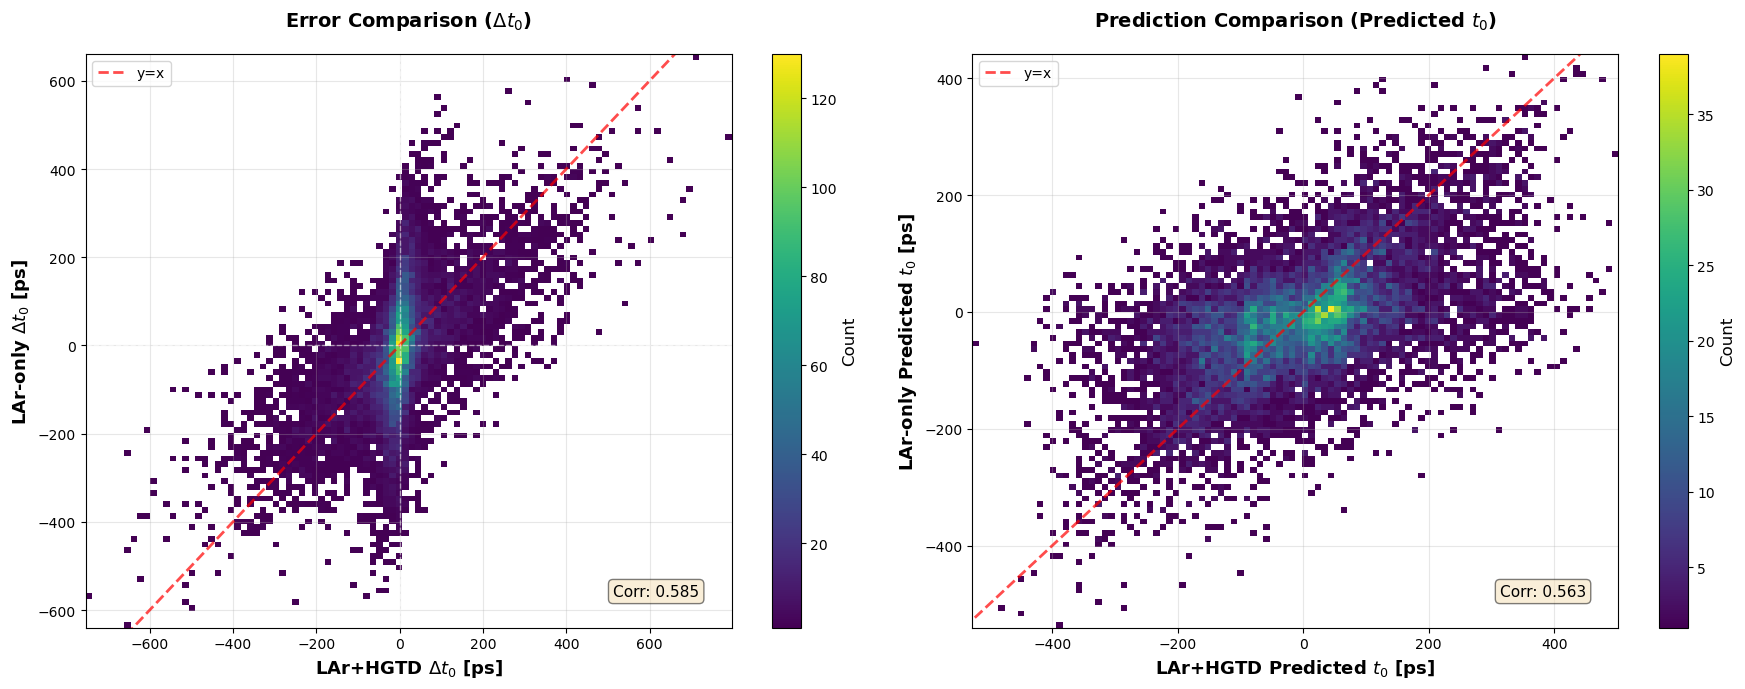


📊 Comparison Summary
Model 1: LAr+HGTD (hgtd_multi_input_dnn_with_jets_tracks)
  Mean Error: 1.3685 ps
  Std Error:  116.3215 ps

Model 2: LAr-only (test_1209_LAr)
  Mean Error: -10.4861 ps
  Std Error:  145.5607 ps

Error Correlation: 0.5848
Prediction Correlation: 0.5626
Total Samples: 10800


In [9]:
# Run verification
verify_identical_ytrue('hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr')

# Example 1: View first 10 predictions (default)
# df = view_predictions('test_1209_LAr_1e2', n=20)

# Example 3: View multiple models
for model in ['hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr']:
    view_predictions(model, n=5)
    print('\n' + '='*80 + '\n')

# Run the comparison
compare_model_errors_2d('hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr',
                        model1_label='LAr+HGTD', model2_label='LAr-only')

✓ Size check: Model1=10800, Model2=10800 → PASS
✓ Values identical (exact): PASS ✅
✓ Event numbers match: PASS ✅
✓ File indices match: PASS ✅
📂 Loading: ../models/hgtd_only_dnn/predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz

📊 Summary Statistics for hgtd_only_dnn
Total samples: 10800
Format: New (with event metadata)
Unique files: 3

Error Statistics:
  Mean Error:   2.601689
  Std Error:    132.895218
  Min Error:    -754.745422
  Max Error:    842.994568
  Median Error: 3.664642

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,604904,0,-2.264550,192.408493,194.673050
1,1,604944,0,168.376068,47.586945,-120.789124
2,2,604942,0,107.262299,102.997826,-4.264473
3,3,604946,0,21.100338,10.083296,-11.017042
4,4,604947,0,-103.677216,-97.397453,6.279762




📂 Loading: ../models/test_1209_LAr/predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz

📊 Summary Statistics for test_1209_LAr
Total samples: 10800
Format: New (with event metadata)
Unique files: 3

Error Statistics:
  Mean Error:   -10.486135
  Std Error:    145.560699
  Min Error:    -639.988647
  Max Error:    661.400879
  Median Error: -9.741501

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,604904,0,-2.264550,-78.191269,-75.926720
1,1,604944,0,168.376068,-353.806946,-522.182983
2,2,604942,0,107.262299,-31.339003,-138.601303
3,3,604946,0,21.100338,38.861935,17.761597
4,4,604947,0,-103.677216,-15.680540,87.996674


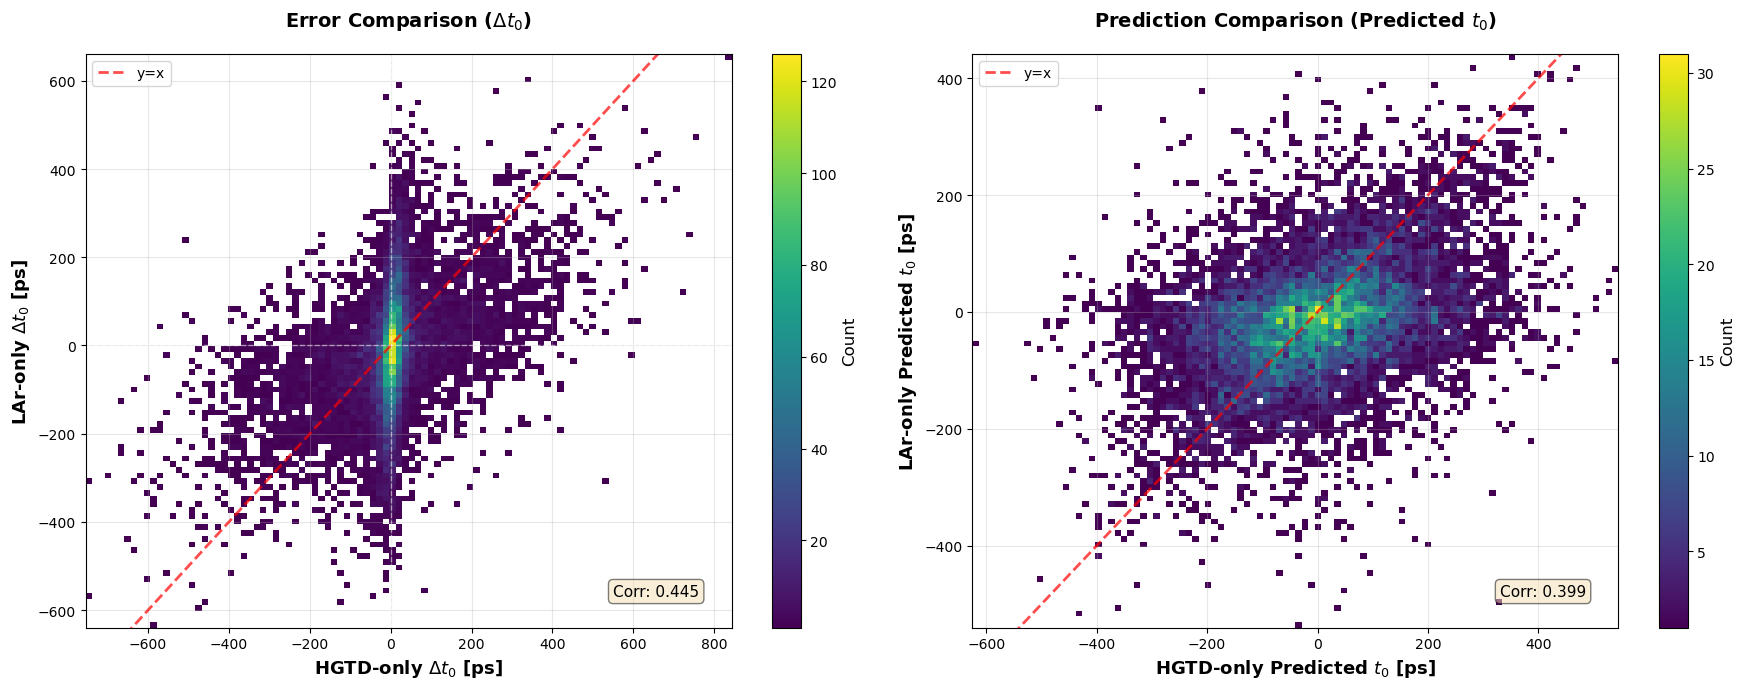


📊 Comparison Summary
Model 1: HGTD-only (hgtd_only_dnn)
  Mean Error: 2.6017 ps
  Std Error:  132.8952 ps

Model 2: LAr-only (test_1209_LAr)
  Mean Error: -10.4861 ps
  Std Error:  145.5607 ps

Error Correlation: 0.4455
Prediction Correlation: 0.3991
Total Samples: 10800


In [10]:
# Run verification
verify_identical_ytrue('hgtd_only_dnn_test', 'test_1209_LAr')

# Example 1: View first 10 predictions (default)
# df = view_predictions('test_1209_LAr_1e2', n=20)

# Example 3: View multiple models
for model in ['hgtd_only_dnn', 'test_1209_LAr']:
    view_predictions(model, n=5)
    print('\n' + '='*80 + '\n')

# Run the comparison
compare_model_errors_2d('hgtd_only_dnn', 'test_1209_LAr',
                        model1_label='HGTD-only', model2_label='LAr-only')

✓ Size check: Model1=10800, Model2=10800 → PASS
✓ Values identical (exact): PASS ✅
✓ Event numbers match: PASS ✅
✓ File indices match: PASS ✅
📂 Loading: ../models/hgtd_multi_input_dnn_with_jets_tracks/predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz

📊 Summary Statistics for hgtd_multi_input_dnn_with_jets_tracks
Total samples: 10800
Format: New (with event metadata)
Unique files: 3

Error Statistics:
  Mean Error:   1.368545
  Std Error:    116.321510
  Min Error:    -753.944946
  Max Error:    797.088623
  Median Error: 0.185066

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,604904,0,-2.264550,178.973312,181.237869
1,1,604944,0,168.376068,-106.612984,-274.989044
2,2,604942,0,107.262299,77.477715,-29.784584
3,3,604946,0,21.100338,57.549690,36.449352
4,4,604947,0,-103.677216,-94.484009,9.193207




📂 Loading: ../models/hgtd_only_dnn_test/predictions_VBF_Hinv_Vertex_timing_HGTD_w_LAr.npz

📊 Summary Statistics for hgtd_only_dnn_test
Total samples: 10800
Format: New (with event metadata)
Unique files: 3

Error Statistics:
  Mean Error:   3.372973
  Std Error:    135.413177
  Min Error:    -793.741760
  Max Error:    864.410889
  Median Error: 4.857475

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,604904,0,-2.264550,179.177032,181.441589
1,1,604944,0,168.376068,48.240162,-120.135910
2,2,604942,0,107.262299,100.589767,-6.672531
3,3,604946,0,21.100338,15.243246,-5.857092
4,4,604947,0,-103.677216,-90.230522,13.446693


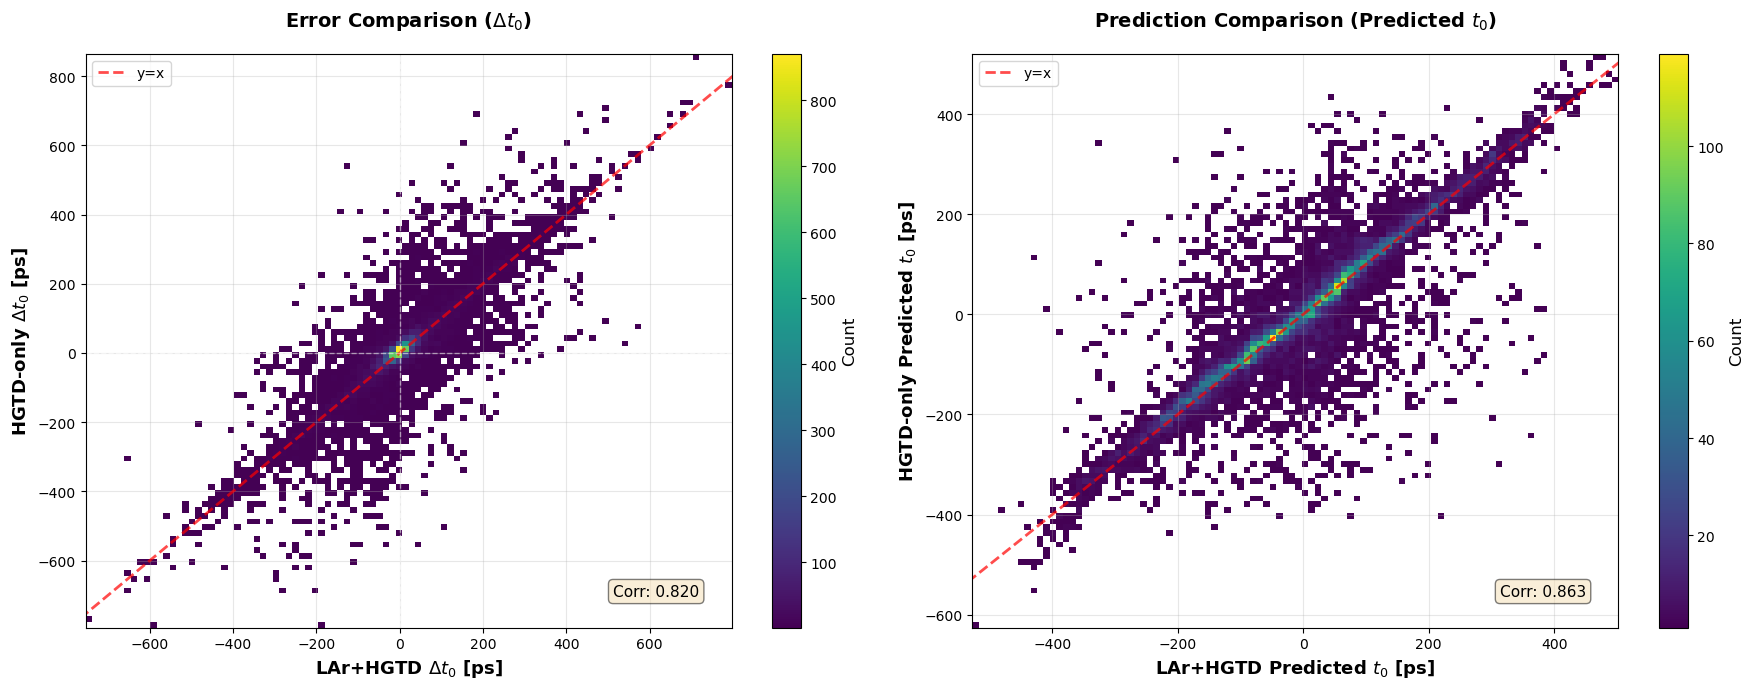


📊 Comparison Summary
Model 1: LAr+HGTD (hgtd_multi_input_dnn_with_jets_tracks)
  Mean Error: 1.3685 ps
  Std Error:  116.3215 ps

Model 2: HGTD-only (hgtd_only_dnn_test)
  Mean Error: 3.3730 ps
  Std Error:  135.4132 ps

Error Correlation: 0.8195
Prediction Correlation: 0.8631
Total Samples: 10800


In [11]:
# Run verification
verify_identical_ytrue('hgtd_multi_input_dnn_with_jets_tracks', 'hgtd_only_dnn_test')

# Example 1: View first 10 predictions (default)
# df = view_predictions('test_1209_LAr_1e2', n=20)

# Example 3: View multiple models
for model in ['hgtd_multi_input_dnn_with_jets_tracks', 'hgtd_only_dnn_test']:
    view_predictions(model, n=5)
    print('\n' + '='*80 + '\n')

# Run the comparison
compare_model_errors_2d('hgtd_multi_input_dnn_with_jets_tracks', 'hgtd_only_dnn_test',
                        model1_label='LAr+HGTD', model2_label='HGTD-only')

In [12]:
data_lar_hgtd = np.load(f'../models/hgtd_multi_input_dnn_with_jets_tracks/{PRED_FILE}')
data_hgtd = np.load(f'../models/hgtd_only_dnn_test/{PRED_FILE}')
data_lar = np.load(f'../models/test_1209_LAr/{PRED_FILE}')

# Extract predictions and true values
y_true = data_lar_hgtd['y_true']  # Should be same for all models
y_pred_lar_hgtd = data_lar_hgtd['y_pred']
y_pred_hgtd = data_hgtd['y_pred']
y_pred_lar = data_lar['y_pred']

# Extract event metadata if available
has_metadata = 'event_numbers' in data_lar_hgtd and 'file_indices' in data_lar_hgtd

# Create DataFrame
df_data = {
    'Index': range(len(y_true)),
}

# Add event metadata if available
if has_metadata:
    df_data['Event_Num'] = data_lar_hgtd['event_numbers']
    df_data['File_Num'] = data_lar_hgtd['file_indices']

# Add predictions and true values
df_data.update({
    'True t₀ [ps]': y_true,
    'LAr+HGTD [ps]': y_pred_lar_hgtd,
    'HGTD-only [ps]': y_pred_hgtd,
    'LAr-only [ps]': y_pred_lar
})

df = pd.DataFrame(df_data)

# Add error columns
df['Error (LAr+HGTD)'] = y_pred_lar_hgtd - y_true
df['Error (HGTD-only)'] = y_pred_hgtd - y_true
df['Error (LAr-only)'] = y_pred_lar - y_true

print("📋 First 20 Events: True Values and Model Predictions")
print("="*120)
if has_metadata:
    print("✓ Event metadata available (Event_Num, File_Num)")
else:
    print("⚠️  No event metadata available in predictions file")
print("="*120)
display(df.head(20))

# Print summary statistics
print("\n📊 Summary Statistics")
print("="*120)
print(f"{'Model':<20} {'Mean Error [ps]':<20} {'Std Error [ps]':<20} {'RMSE [ps]':<20}")
print("-"*120)

for model_name, errors in [
    ('LAr+HGTD', df['Error (LAr+HGTD)']),
    ('HGTD-only', df['Error (HGTD-only)']),
    ('LAr-only', df['Error (LAr-only)'])
]:
    mean_err = errors.mean()
    std_err = errors.std()
    rmse = np.sqrt((errors**2).mean())
    print(f"{model_name:<20} {mean_err:<20.4f} {std_err:<20.4f} {rmse:<20.4f}")

if has_metadata:
    print(f"\n📊 Dataset Information")
    print("="*80)
    print(f"Total events: {len(df)}")
    print(f"Unique file indices: {df['File_Num'].nunique()}")
    print(f"File index range: {df['File_Num'].min()} - {df['File_Num'].max()}")

📋 First 20 Events: True Values and Model Predictions
✓ Event metadata available (Event_Num, File_Num)


,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],LAr-only [ps],Error (LAr+HGTD),Error (HGTD-only),Error (LAr-only)
0,0,604904,0,-2.264550,178.973312,179.177032,-78.191269,181.237869,181.441589,-75.926720
1,1,604944,0,168.376068,-106.612984,48.240162,-353.806946,-274.989044,-120.135910,-522.182983
2,2,604942,0,107.262299,77.477715,100.589767,-31.339003,-29.784584,-6.672531,-138.601303
3,3,604946,0,21.100338,57.549690,15.243246,38.861935,36.449352,-5.857092,17.761597
4,4,604947,0,-103.677216,-94.484009,-90.230522,-15.680540,9.193207,13.446693,87.996674
5,5,604945,0,52.992065,66.189171,64.587006,67.995010,13.197105,11.594940,15.002945
6,6,604941,0,187.996933,175.592514,192.281082,-76.312027,-12.404419,4.284149,-264.308960
7,7,604952,0,103.794800,92.026062,97.630081,6.090256,-11.768738,-6.164719,-97.704544
8,8,604950,0,84.393852,-108.434692,-140.842957,10.498717,-192.828552,-225.236816,-73.895134
9,9,604951,0,175.144791,103.160484,117.542839,97.431595,-71.984306,-57.601952,-77.713196



📊 Summary Statistics
Model                Mean Error [ps]      Std Error [ps]       RMSE [ps]           
------------------------------------------------------------------------------------------------------------------------
LAr+HGTD             1.3685               116.3268             116.3296            
HGTD-only            3.3730               135.4193             135.4552            
LAr-only             -10.4861             145.5672             145.9379            

📊 Dataset Information
Total events: 10800
Unique file indices: 3
File index range: 0 - 2


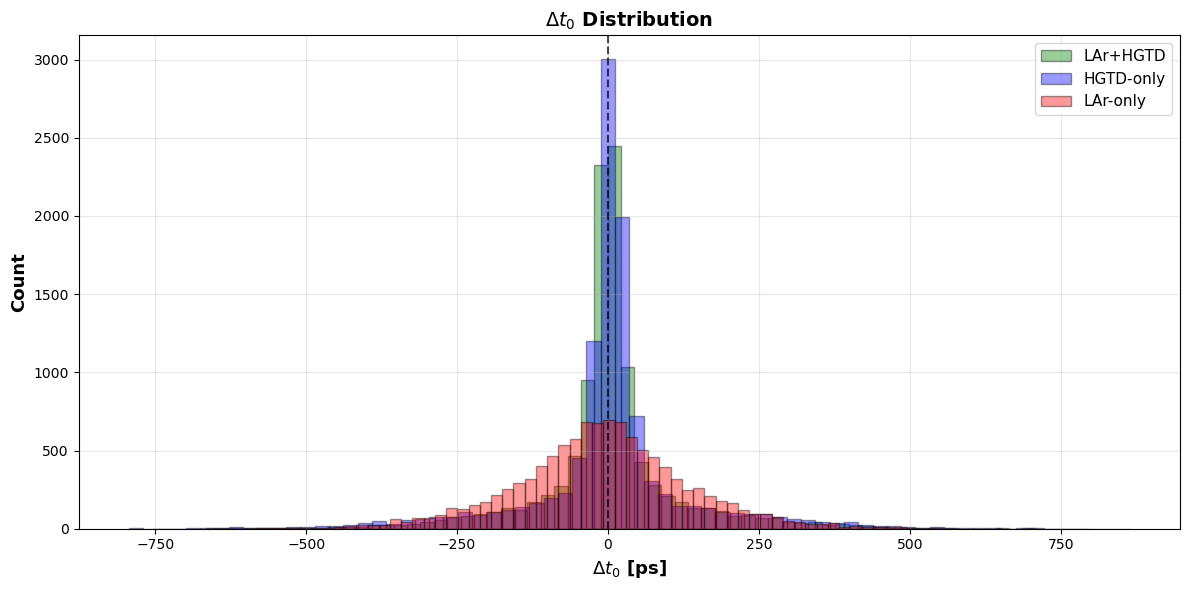


📊 Comparison: All Three Models
Model           Mean [ps]       Std [ps]        RMSE [ps]      
--------------------------------------------------------------------------------
LAr+HGTD                1.3685       116.3268       116.3296
HGTD-only               3.3730       135.4193       135.4552
LAr-only              -10.4861       145.5672       145.9379


In [13]:
plt.figure(figsize=(12, 6))

# Plot all three error distributions
plt.hist(df['Error (LAr+HGTD)'], bins=70, alpha=0.4, label='LAr+HGTD', color='green', edgecolor='black')
plt.hist(df['Error (HGTD-only)'], bins=70, alpha=0.4, label='HGTD-only', color='blue', edgecolor='black')
plt.hist(df['Error (LAr-only)'], bins=70, alpha=0.4, label='LAr-only', color='red', edgecolor='black')

plt.xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.title('$\\Delta t_0$ Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n📊 Comparison: All Three Models")
print("="*80)
print(f"{'Model':<15} {'Mean [ps]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*80)
print(f"{'LAr+HGTD':<15} {df['Error (LAr+HGTD)'].mean():>14.4f} {df['Error (LAr+HGTD)'].std():>14.4f} {np.sqrt((df['Error (LAr+HGTD)']**2).mean()):>14.4f}")
print(f"{'HGTD-only':<15} {df['Error (HGTD-only)'].mean():>14.4f} {df['Error (HGTD-only)'].std():>14.4f} {np.sqrt((df['Error (HGTD-only)']**2).mean()):>14.4f}")
print(f"{'LAr-only':<15} {df['Error (LAr-only)'].mean():>14.4f} {df['Error (LAr-only)'].std():>14.4f} {np.sqrt((df['Error (LAr-only)']**2).mean()):>14.4f}")

In [14]:
# Filter events based on model comparison
comparison = 'better'  # Change to 'better' or 'worse'

# Calculate which model performs better for each event
df['LAr+HGTD_abs_error'] = np.abs(df['Error (LAr+HGTD)'])
df['HGTD-only_abs_error'] = np.abs(df['Error (HGTD-only)'])

if comparison == 'better':
    # LAr+HGTD is better than HGTD-only (smaller absolute error)
    filtered_df = df[df['LAr+HGTD_abs_error'] < df['HGTD-only_abs_error']].copy()
    title = "LAr+HGTD performs BETTER than HGTD-only"
else:
    # LAr+HGTD is worse than HGTD-only (larger absolute error)
    filtered_df = df[df['LAr+HGTD_abs_error'] > df['HGTD-only_abs_error']].copy()
    title = "LAr+HGTD performs WORSE than HGTD-only"

print(f"📋 Events where {title}")
print(f"{'='*120}")
print(f"Found {len(filtered_df)} events out of {len(df)} total ({100*len(filtered_df)/len(df):.2f}%)")
print(f"{'='*120}\n")

# Add improvement/degradation column
filtered_df['Improvement'] = filtered_df['HGTD-only_abs_error'] - filtered_df['LAr+HGTD_abs_error']

# Sort by improvement (positive = better, negative = worse)
filtered_df = filtered_df.sort_values('Improvement', ascending=False)

# Display results - include metadata if available
display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr+HGTD [ps]', 'HGTD-only [ps]',
                    'Error (LAr+HGTD)', 'Error (HGTD-only)', 'Improvement'])

display(filtered_df[display_cols])

# Print statistics for filtered events
print(f"\n📊 Statistics for filtered events")
print(f"{'='*80}")
print(f"Average improvement: {filtered_df['Improvement'].mean():.4f} ps")
print(f"Max improvement: {filtered_df['Improvement'].max():.4f} ps")
print(f"Min improvement: {filtered_df['Improvement'].min():.4f} ps")
print(f"\n{'Model':<15} {'Mean Error [ps]':<20} {'Std Error [ps]':<20} {'RMSE [ps]':<15}")
print("-"*80)
for model_name in ['LAr+HGTD', 'HGTD-only']:
    errors = filtered_df[f'Error ({model_name})']
    print(f"{model_name:<15} {errors.mean():>19.4f} {errors.std():>19.4f} {np.sqrt((errors**2).mean()):>14.4f}")

# Print top 20 events with biggest improvement/degradation
print(f"\n📊 Top 20 Events (Sorted by {'Improvement' if comparison == 'better' else 'Degradation'})")
print(f"{'='*80}")
top_events_cols = ['Index']
if has_metadata:
    top_events_cols.extend(['Event_Num', 'File_Num'])
top_events_cols.extend(['True t₀ [ps]', 'HGTD-only [ps]', 'LAr+HGTD [ps]', 'Improvement'])
display(filtered_df[top_events_cols].head(20))

📋 Events where LAr+HGTD performs BETTER than HGTD-only
Found 5710 events out of 10800 total (52.87%)



,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],Error (LAr+HGTD),Error (HGTD-only),Improvement
725,725,605642,0,491.633484,308.554443,-302.108276,-183.079041,-793.741760,610.662720
9238,9238,206161,2,231.222290,202.711929,-316.620880,-28.510361,-547.843140,519.332764
3205,3205,500765,1,304.958679,306.443268,-209.545197,1.484589,-514.503906,513.019287
10075,10075,206931,2,-384.614594,-202.583694,304.307495,182.030899,688.922119,506.891235
9038,9038,205964,2,311.893372,362.705353,-238.849380,50.811981,-550.742737,499.930756
...,...,...,...,...,...,...,...,...,...
3652,3652,501172,1,44.013260,22.342566,22.321201,-21.670694,-21.692059,0.021364
7422,7422,204316,2,-34.135445,-44.050564,-44.071846,-9.915119,-9.936401,0.021282
8105,8105,205089,2,-58.083527,-62.269672,-53.880028,-4.186146,4.203499,0.017353
3633,3633,501132,1,-18.293205,-45.410580,-45.418976,-27.117374,-27.125771,0.008396



📊 Statistics for filtered events
Average improvement: 41.5472 ps
Max improvement: 610.6627 ps
Min improvement: 0.0034 ps

Model           Mean Error [ps]      Std Error [ps]       RMSE [ps]      
--------------------------------------------------------------------------------
LAr+HGTD                     7.1028            111.2905       111.5074
HGTD-only                    9.7916            163.8155       164.0938

📊 Top 20 Events (Sorted by Improvement)


,Index,Event_Num,File_Num,True t₀ [ps],HGTD-only [ps],LAr+HGTD [ps],Improvement
725,725,605642,0,491.633484,-302.108276,308.554443,610.662720
9238,9238,206161,2,231.222290,-316.620880,202.711929,519.332764
3205,3205,500765,1,304.958679,-209.545197,306.443268,513.019287
10075,10075,206931,2,-384.614594,304.307495,-202.583694,506.891235
9038,9038,205964,2,311.893372,-238.849380,362.705353,499.930756
5533,5533,202419,2,274.750549,-332.639404,161.826065,494.465454
6765,6765,203666,2,282.022156,-398.991669,78.244980,477.236633
10198,10198,207063,2,401.721497,-94.425926,375.234833,469.660767
4859,4859,201622,2,444.748383,-113.341782,349.354034,462.695801
8654,8654,205546,2,427.476135,-76.254616,384.744232,460.998840


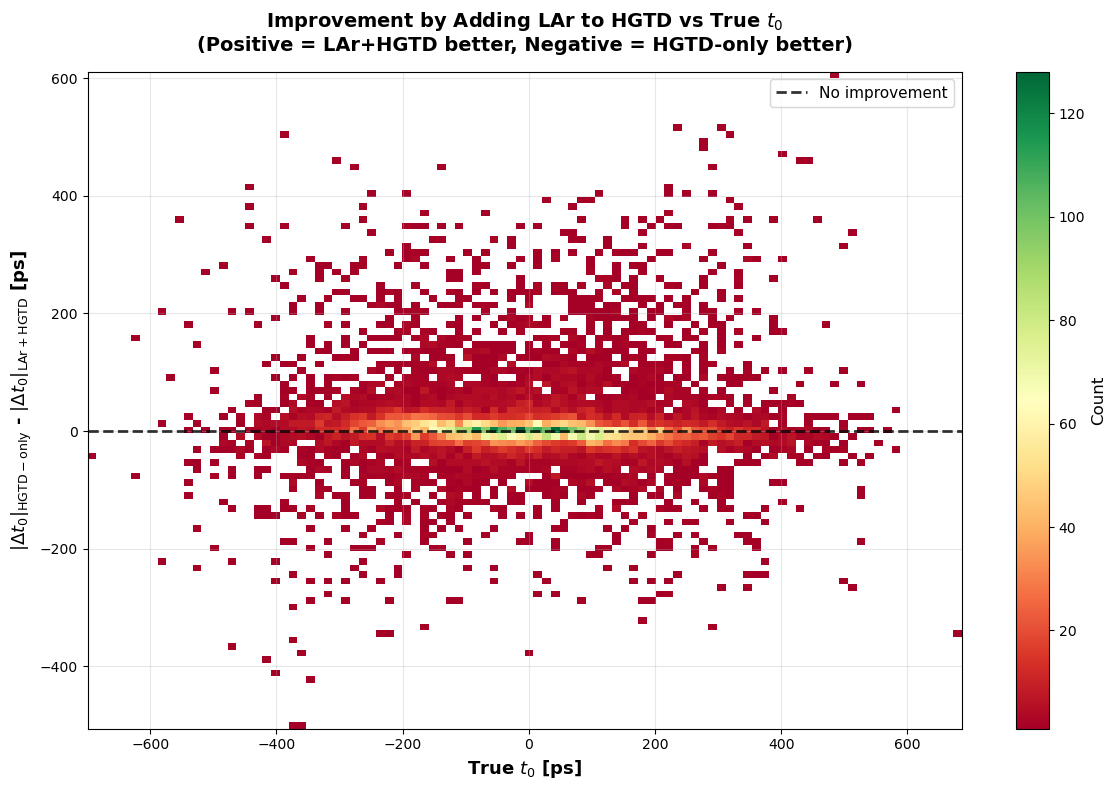

📊 Overall Improvement Statistics
Mean improvement: 9.2063 ps
Median improvement: 1.0869 ps
Std improvement: 69.1586 ps
Events where LAr+HGTD better: 5710 (52.87%)
Events where HGTD-only better: 5090 (47.13%)


In [15]:
# 2D Histogram: Truth time vs Improvement
plt.figure(figsize=(12, 8))

# Calculate improvement: |HGTD-only error| - |LAr+HGTD error|
# Positive values mean LAr+HGTD is better
improvement = df['HGTD-only_abs_error'] - df['LAr+HGTD_abs_error']

h = plt.hist2d(df['True t₀ [ps]'], improvement, 
               bins=100, cmap='RdYlGn', cmin=1)

cbar = plt.colorbar(h[3])
cbar.set_label('Count', fontsize=12)

plt.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.8, label='No improvement')
plt.xlabel('True $t_0$ [ps]', fontsize=13, fontweight='bold')
plt.ylabel('$|\\Delta t_0|_{\\mathrm{HGTD-only}}$ - $|\\Delta t_0|_{\\mathrm{LAr+HGTD}}$ [ps]', fontsize=13, fontweight='bold')
plt.title('Improvement by Adding LAr to HGTD vs True $t_0$\n(Positive = LAr+HGTD better, Negative = HGTD-only better)', 
          fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Overall Improvement Statistics")
print(f"{'='*60}")
print(f"Mean improvement: {improvement.mean():.4f} ps")
print(f"Median improvement: {improvement.median():.4f} ps")
print(f"Std improvement: {improvement.std():.4f} ps")
print(f"Events where LAr+HGTD better: {(improvement > 0).sum()} ({100*(improvement > 0).sum()/len(improvement):.2f}%)")
print(f"Events where HGTD-only better: {(improvement < 0).sum()} ({100*(improvement < 0).sum()/len(improvement):.2f}%)")

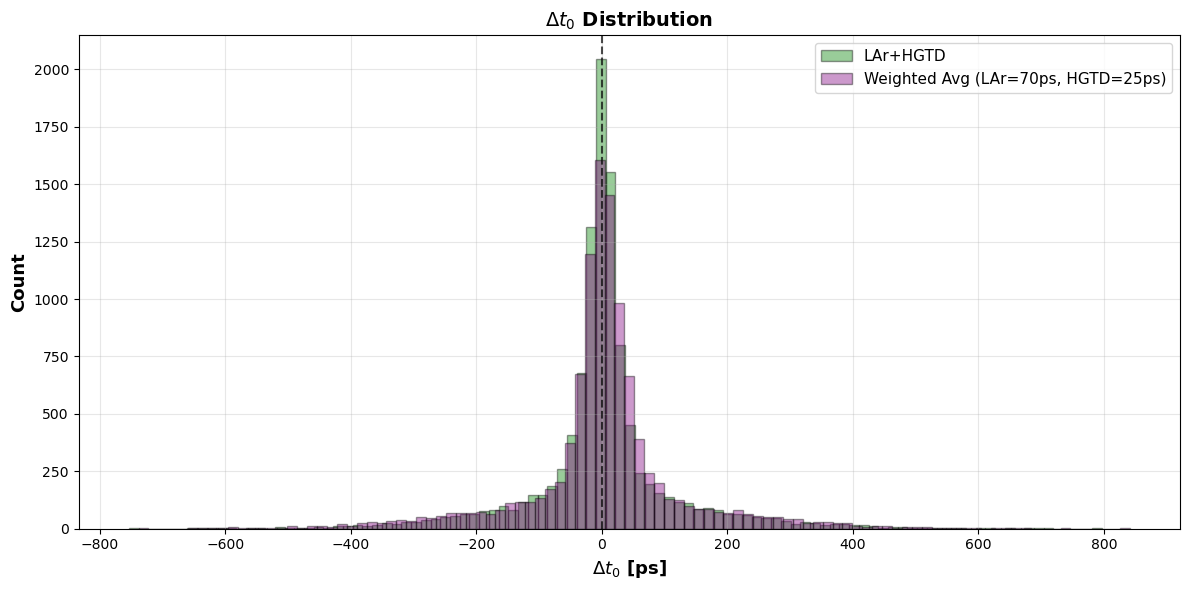


📊 Comparison: All Four Models
Model                     Mean [ps]       Std [ps]        RMSE [ps]      
--------------------------------------------------------------------------------
LAr+HGTD                          1.3685       116.3268       116.3296
HGTD-only                         3.3730       135.4193       135.4552
LAr-only                        -10.4861       145.5672       145.9379
Weighted Avg                      1.8052       128.3066       128.3134


In [16]:
x = 70  # LAr time resolution in ps
y = 25  # HGTD time resolution in ps

weight_lar = 1 / (x**2)
weight_hgtd = 1 / (y**2)
weight_sum = weight_lar + weight_hgtd

df['Weighted Average [ps]'] = (y_pred_lar * weight_lar + y_pred_hgtd * weight_hgtd) / weight_sum
df['Error (Weighted Avg)'] = df['Weighted Average [ps]'] - y_true

plt.figure(figsize=(12, 6))

plt.hist(df['Error (LAr+HGTD)'], bins=100, alpha=0.4, label='LAr+HGTD', color='green', edgecolor='black')
plt.hist(df['Error (Weighted Avg)'], bins=100, alpha=0.4, label=f'Weighted Avg (LAr={x}ps, HGTD={y}ps)', color='purple', edgecolor='black')

plt.xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.title('$\\Delta t_0$ Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.tight_layout()
plt.show()

print("\n📊 Comparison: All Four Models")
print("="*80)
print(f"{'Model':<25} {'Mean [ps]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*80)
print(f"{'LAr+HGTD':<25} {df['Error (LAr+HGTD)'].mean():>14.4f} {df['Error (LAr+HGTD)'].std():>14.4f} {np.sqrt((df['Error (LAr+HGTD)']**2).mean()):>14.4f}")
print(f"{'HGTD-only':<25} {df['Error (HGTD-only)'].mean():>14.4f} {df['Error (HGTD-only)'].std():>14.4f} {np.sqrt((df['Error (HGTD-only)']**2).mean()):>14.4f}")
print(f"{'LAr-only':<25} {df['Error (LAr-only)'].mean():>14.4f} {df['Error (LAr-only)'].std():>14.4f} {np.sqrt((df['Error (LAr-only)']**2).mean()):>14.4f}")
print(f"{'Weighted Avg':<25} {df['Error (Weighted Avg)'].mean():>14.4f} {df['Error (Weighted Avg)'].std():>14.4f} {np.sqrt((df['Error (Weighted Avg)']**2).mean()):>14.4f}")

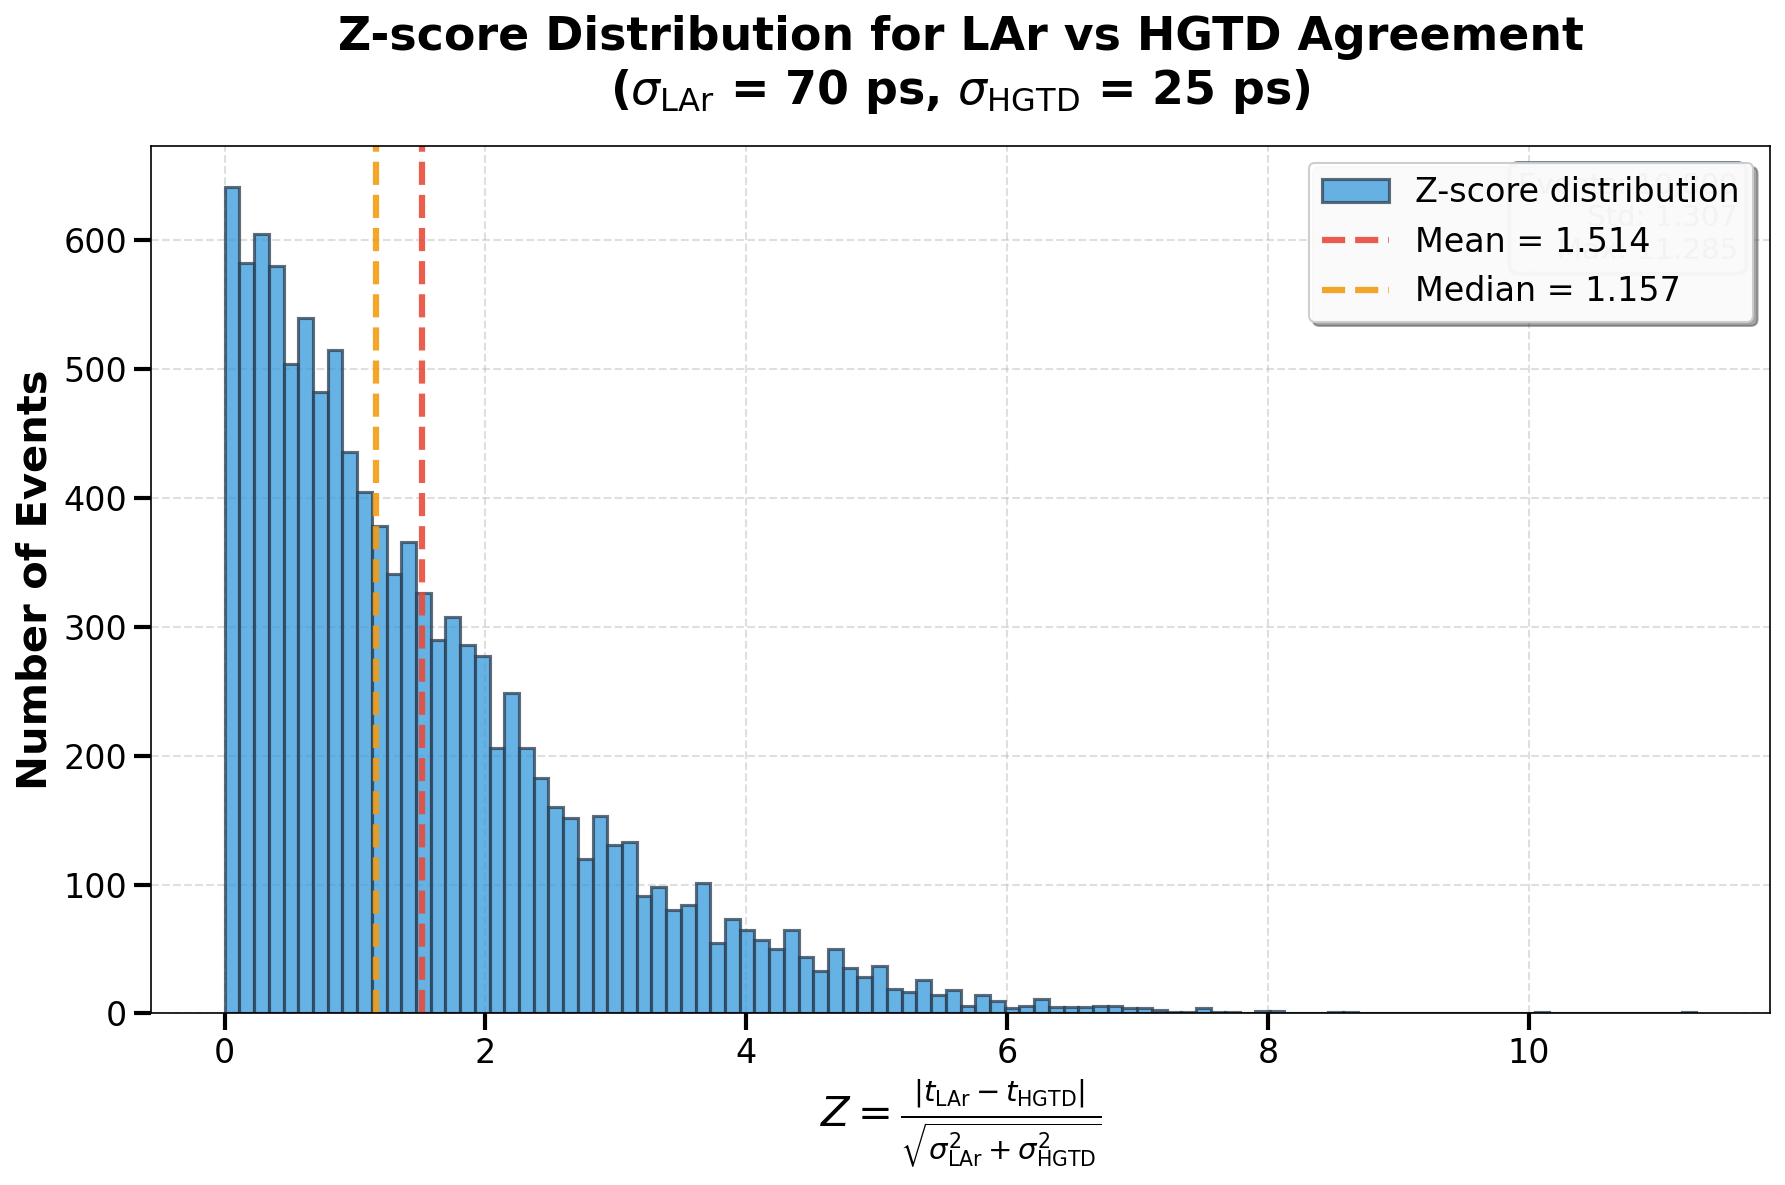

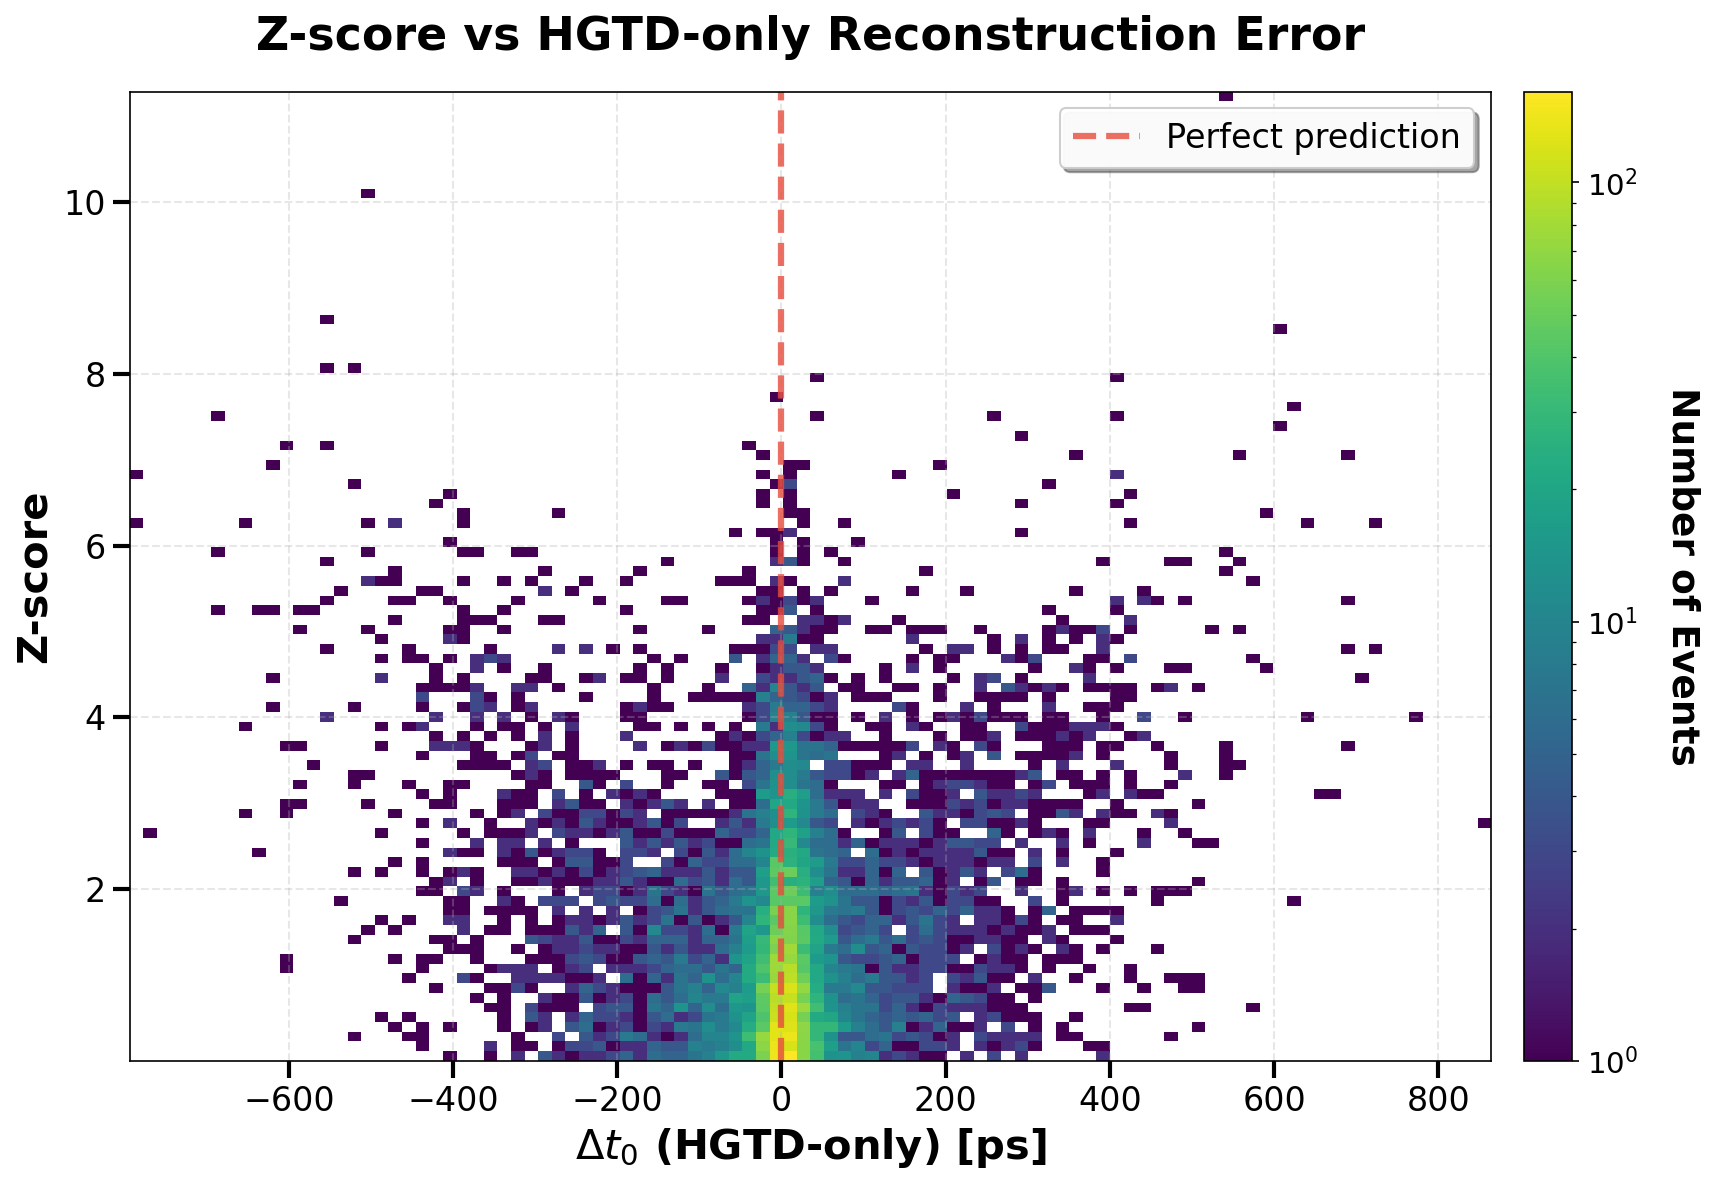

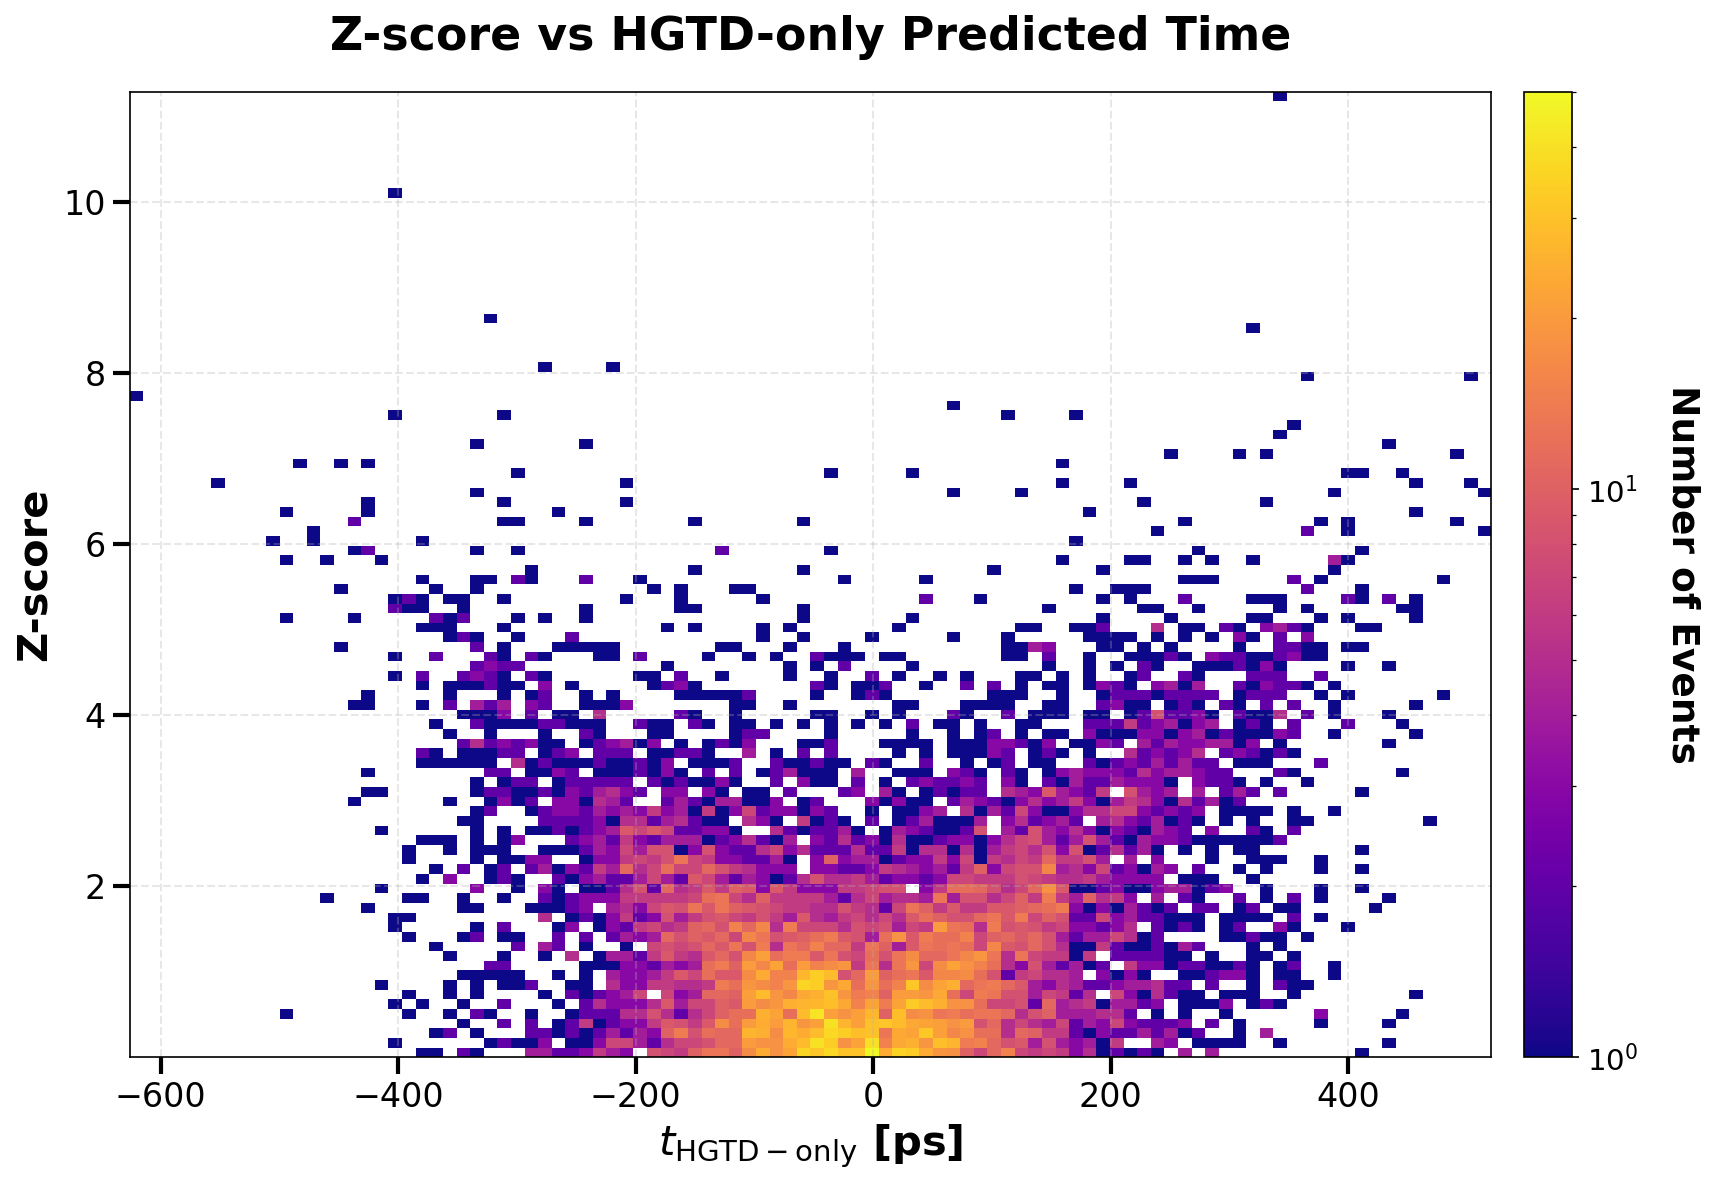

📊 Z-score Statistics
Mean Z-score:        1.5142
Median Z-score:      1.1573
Std Z-score:         1.3068
Max Z-score:         11.2854
Min Z-score:         0.0000

Events with Z > 1:   5980 (55.37%)
Events with Z > 2:   3026 (28.02%)
Events with Z > 3:   1426 (13.20%)

🔝 Top 10 Events with HIGHEST Z-score


,Index,Event_Num,File_Num,True t₀ [ps],LAr-only [ps],HGTD-only [ps],Error (LAr-only),Error (HGTD-only),Z_score
4444,4444,201232,2,-197.909454,-500.183411,338.666321,-302.273956,536.575806,11.285428
6342,6342,203283,2,107.633919,350.428192,-398.876587,242.794281,-506.510498,10.080739
9238,9238,206161,2,231.222290,320.951965,-316.620880,89.729675,-547.843140,8.577559
8100,8100,205001,2,-281.795135,-309.350189,320.966858,-27.555054,602.761963,8.479942
9982,9982,206869,2,286.164795,326.254822,-275.077545,40.090027,-561.242310,8.089999
5669,5669,202574,2,297.626343,373.323822,-224.480698,75.697479,-522.107056,8.042537
10702,10702,207673,2,466.175049,-84.195267,507.337891,-550.370300,41.162842,7.958165
3946,3946,501451,1,-31.334736,-218.543442,369.411224,-187.208710,400.745972,7.910022
10379,10379,207293,2,-616.100464,-51.850929,-626.001526,564.249512,-9.901062,7.724309
1182,1182,606043,0,-556.180298,-501.633362,68.079453,54.546936,624.259766,7.664606



🔻 Top 10 Events with LOWEST Z-score


,Index,Event_Num,File_Num,True t₀ [ps],LAr-only [ps],HGTD-only [ps],Error (LAr-only),Error (HGTD-only),Z_score
4369,4369,201149,2,-31.984081,-13.478509,-13.478983,18.505573,18.505098,0.000006
4792,4792,201590,2,-81.041580,-85.148560,-85.183022,-4.106979,-4.141441,0.000464
4593,4593,201398,2,36.064068,-10.774154,-10.821434,-46.838223,-46.885502,0.000636
7151,7151,204010,2,-17.677391,-22.711458,-22.659035,-5.034067,-4.981644,0.000705
552,552,605463,0,46.121040,46.980350,47.033405,0.859310,0.912365,0.000714
8717,8717,205621,2,-40.012138,-3.127208,-3.186220,36.884930,36.825920,0.000794
9015,9015,205991,2,77.172104,73.753510,73.691017,-3.418594,-3.481087,0.000841
973,973,605835,0,-317.009644,-247.091583,-246.993011,69.918060,70.016632,0.001326
2060,2060,606972,0,-40.375702,-44.315918,-44.446255,-3.940216,-4.070553,0.001753
7988,7988,204844,2,-123.243111,-90.697342,-90.893486,32.545769,32.349625,0.002639



📊 Summary of Extreme Z-score Events
Category             Mean Z-score    Mean |Error(LAr)|    Mean |Error(HGTD)|  
--------------------------------------------------------------------------------
Top 10 Highest               7.9565            221.7420            409.4742
Top 10 Lowest                0.0010             22.2052             22.2170


In [25]:
# Calculate Z-score: |t_LAr - t_HGTD| / sqrt(sigma_LAr^2 + sigma_HGTD^2)
sigma_lar = 70  # ps
sigma_hgtd = 25  # ps

df['Z_score'] = np.abs(y_pred_lar - y_pred_hgtd) / np.sqrt(sigma_lar**2 + sigma_hgtd**2)
df['HGTD_error'] = y_pred_hgtd - y_true

# ====================================================================
# Figure 1: Z-score Distribution (High Quality, Beautiful)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Plot histogram with beautiful styling
n, bins, patches = ax.hist(df['Z_score'], bins=100, alpha=0.75, 
                           color='#3498db', edgecolor='#2c3e50', linewidth=1.5,
                           label='Z-score distribution')

# Add mean and median lines
mean_z = df['Z_score'].mean()
median_z = df['Z_score'].median()

ax.axvline(x=mean_z, color='#e74c3c', linestyle='--', linewidth=3, 
           label=f'Mean = {mean_z:.3f}', alpha=0.9)
ax.axvline(x=median_z, color='#f39c12', linestyle='--', linewidth=3,
           label=f'Median = {median_z:.3f}', alpha=0.9)

# Labels and title with larger fonts
ax.set_xlabel('$Z = \\frac{|t_{\\mathrm{LAr}} - t_{\\mathrm{HGTD}}|}{\\sqrt{\\sigma_{\\mathrm{LAr}}^2 + \\sigma_{\\mathrm{HGTD}}^2}}$', 
              fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=20, fontweight='bold')
ax.set_title(f'Z-score Distribution for LAr vs HGTD Agreement\n($\\sigma_{{\\mathrm{{LAr}}}}$ = {sigma_lar} ps, $\\sigma_{{\\mathrm{{HGTD}}}}$ = {sigma_hgtd} ps)', 
             fontsize=22, fontweight='bold', pad=20)

# Enhanced legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid styling
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
ax.tick_params(axis='both', which='minor', labelsize=14, width=1.5, length=5)

# Add statistics box
stats_text = f'Events: {len(df):,}\nStd: {df["Z_score"].std():.3f}\nMax: {df["Z_score"].max():.3f}'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=14, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#34495e', linewidth=2))

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 2: Z-score vs HGTD Error (2D Histogram)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(df['HGTD_error'], df['Z_score'], bins=100, 
              cmap='viridis', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Perfect prediction line
ax.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=3, 
           alpha=0.8, label='Perfect prediction')

# Labels and title
ax.set_xlabel('$\\Delta t_0$ (HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Reconstruction Error', 
             fontsize=22, fontweight='bold', pad=20)

# Legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 3: Z-score vs HGTD Prediction Value
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(y_pred_hgtd, df['Z_score'], bins=100, 
              cmap='plasma', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Labels and title
ax.set_xlabel('$t_{\\mathrm{HGTD-only}}$ [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Predicted Time', 
             fontsize=22, fontweight='bold', pad=20)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Print Statistics
# ====================================================================
print("📊 Z-score Statistics")
print("="*60)
print(f"Mean Z-score:        {df['Z_score'].mean():.4f}")
print(f"Median Z-score:      {df['Z_score'].median():.4f}")
print(f"Std Z-score:         {df['Z_score'].std():.4f}")
print(f"Max Z-score:         {df['Z_score'].max():.4f}")
print(f"Min Z-score:         {df['Z_score'].min():.4f}")
print(f"\nEvents with Z > 1:   {(df['Z_score'] > 1).sum()} ({100*(df['Z_score'] > 1).sum()/len(df):.2f}%)")
print(f"Events with Z > 2:   {(df['Z_score'] > 2).sum()} ({100*(df['Z_score'] > 2).sum()/len(df):.2f}%)")
print(f"Events with Z > 3:   {(df['Z_score'] > 3).sum()} ({100*(df['Z_score'] > 3).sum()/len(df):.2f}%)")

# Top 10 highest Z-score events
print("\n" + "="*120)
print("🔝 Top 10 Events with HIGHEST Z-score")
print("="*120)
top_10_high = df.nlargest(20, 'Z_score')
display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr-only [ps]', 'HGTD-only [ps]', 
                    'Error (LAr-only)', 'Error (HGTD-only)', 'Z_score'])
display(top_10_high[display_cols])

# Top 10 lowest Z-score events
print("\n" + "="*120)
print("🔻 Top 10 Events with LOWEST Z-score")
print("="*120)
top_10_low = df.nsmallest(10, 'Z_score')
display(top_10_low[display_cols])

# Summary statistics for these events
print("\n📊 Summary of Extreme Z-score Events")
print("="*80)
print(f"{'Category':<20} {'Mean Z-score':<15} {'Mean |Error(LAr)|':<20} {'Mean |Error(HGTD)|':<20}")
print("-"*80)
print(f"{'Top 10 Highest':<20} {top_10_high['Z_score'].mean():>14.4f} "
      f"{top_10_high['Error (LAr-only)'].abs().mean():>19.4f} "
      f"{top_10_high['Error (HGTD-only)'].abs().mean():>19.4f}")
print(f"{'Top 10 Lowest':<20} {top_10_low['Z_score'].mean():>14.4f} "
      f"{top_10_low['Error (LAr-only)'].abs().mean():>19.4f} "
      f"{top_10_low['Error (HGTD-only)'].abs().mean():>19.4f}")

📊 Applying Z-score cut: Z ≤ 2.0
Events before cut: 10800
Events after cut:  7774 (71.98%)
Events removed:    3026 (28.02%)


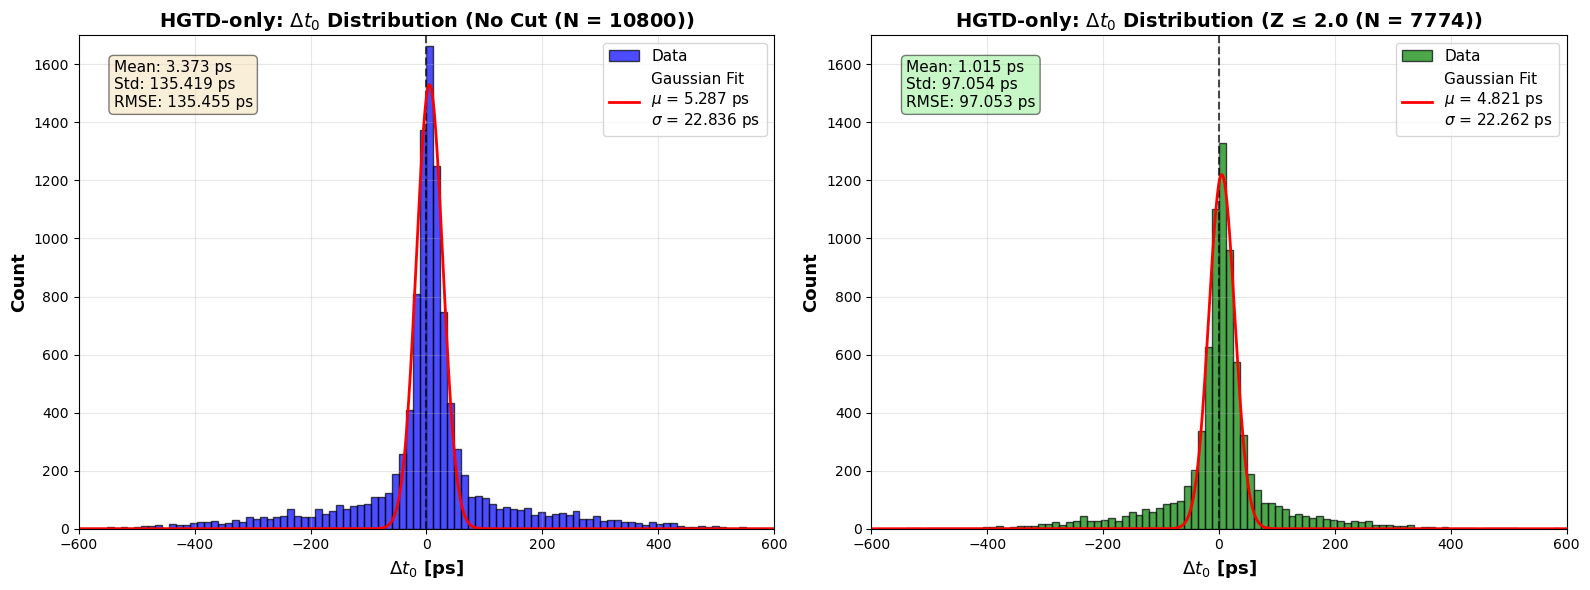


📊 HGTD-only Performance Comparison
Metric               No Cut               Z ≤ 2.0              Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3730              1.0152              2.3578
Std [ps]                        135.4130             97.0478             38.3652
RMSE [ps]                       135.4552             97.0532             38.4019

📊 HGTD-only Performance Comparison
Metric               No Cut               Z ≤ 2.0              Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3730              1.0152              2.3578
Std [ps]                        135.4130             97.0478             38.3652
RMSE [ps]                       135.4552             97.0532             38.4019

🔴 Top 10 Events with LARGEST |Δt₀| after Z-score cut (Z ≤ 2.0)


,Index,Event_Num,File_Num,True t₀ [ps],LAr-only [ps],HGTD-only [ps],Error (LAr-only),Error (HGTD-only),Abs_Error_HGTD,Z_score
5374,5374,202185,2,-473.026855,7.301315,145.228683,480.328186,618.255554,618.255554,1.855600
8295,8295,205139,2,503.105591,-19.079050,-104.338295,-522.184631,-607.443909,607.443909,1.147032
10703,10703,207672,2,500.954346,-22.264162,-102.936623,-523.218506,-603.890991,603.890991,1.085323
759,759,605680,0,-483.252045,48.125889,97.188683,531.377930,580.440735,580.440735,0.660064
3135,3135,500610,1,462.536560,70.790344,-65.904015,-391.746216,-528.440552,528.440552,1.839012
5784,5784,202618,2,332.951630,-83.948318,-191.905548,-416.899963,-524.857178,524.857178,1.452398
5906,5906,202838,2,448.236664,-92.978592,-72.540138,-541.215271,-520.776794,520.776794,0.274968
3563,3563,501066,1,-357.209137,88.913628,156.896820,446.122772,514.105957,514.105957,0.914609
3517,3517,501107,1,-426.030914,14.385227,81.002975,440.416138,507.033875,507.033875,0.896239
8654,8654,205546,2,427.476135,40.473934,-76.254616,-387.002197,-503.730743,503.730743,1.570402



📊 Analysis of Top 10 Worst Events (after cut)
Mean |Error|:           550.898 ps
Mean Z-score:           1.170
Mean True t₀:           93.574 ps
Mean Predicted t₀:      -13.356 ps


In [18]:
from scipy.optimize import curve_fit

# Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Specify Z-score cut threshold
z_cut = 2.0  # Change this value as needed

# Apply Z-score cut
df_filtered = df[df['Z_score'] <= z_cut].copy()

print(f"📊 Applying Z-score cut: Z ≤ {z_cut}")
print("="*80)
print(f"Events before cut: {len(df)}")
print(f"Events after cut:  {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")
print(f"Events removed:    {len(df) - len(df_filtered)} ({100*(len(df) - len(df_filtered))/len(df):.2f}%)")
print("="*80)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (data, title, color) in enumerate([
    (df['Error (HGTD-only)'], f'No Cut (N = {len(df)})', 'blue'),
    (df_filtered['Error (HGTD-only)'], f'Z ≤ {z_cut} (N = {len(df_filtered)})', 'green')
]):
    # Histogram
    n, bins, _ = axes[idx].hist(data, bins=100, alpha=0.7, color=color, edgecolor='black', label='Data', range=(-600, 600))
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Gaussian fit
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, _ = curve_fit(gaussian, bin_centers, n, p0=[n.max(), data.mean(), data.std()])
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    axes[idx].plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2, 
                   label=f'Gaussian Fit\n$\\mu$ = {popt[1]:.3f} ps\n$\\sigma$ = {abs(popt[2]):.3f} ps')
    
    # Labels and text
    axes[idx].set_xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=13, fontweight='bold')
    axes[idx].set_title(f'HGTD-only: $\\Delta t_0$ Distribution ({title})', fontsize=14, fontweight='bold')
    axes[idx].set_xlim(-600, 600)
    axes[idx].set_ylim(0, 1700)
    axes[idx].legend(fontsize=11, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0.05, 0.95, f'Mean: {data.mean():.3f} ps\nStd: {data.std():.3f} ps\nRMSE: {np.sqrt((data**2).mean()):.3f} ps',
                   transform=axes[idx].transAxes, fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat' if idx==0 else 'lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'Z ≤ ' + str(z_cut):<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before, after = func(df['Error (HGTD-only)']), func(df_filtered['Error (HGTD-only)'])
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

    # Print statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'Z ≤ ' + str(z_cut):<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before, after = func(df['Error (HGTD-only)']), func(df_filtered['Error (HGTD-only)'])
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

# Top 10 events with largest |Delta t0| after applying cut
print("\n" + "="*120)
print(f"🔴 Top 10 Events with LARGEST |Δt₀| after Z-score cut (Z ≤ {z_cut})")
print("="*120)

# Calculate absolute error and sort
df_filtered['Abs_Error_HGTD'] = df_filtered['Error (HGTD-only)'].abs()
top_10_error = df_filtered.nlargest(10, 'Abs_Error_HGTD')

display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr-only [ps]', 'HGTD-only [ps]', 
                    'Error (LAr-only)', 'Error (HGTD-only)', 
                    'Abs_Error_HGTD', 'Z_score'])
display(top_10_error[display_cols])

# Summary of these problematic events
print("\n📊 Analysis of Top 10 Worst Events (after cut)")
print("="*80)
print(f"Mean |Error|:           {top_10_error['Abs_Error_HGTD'].mean():.3f} ps")
print(f"Mean Z-score:           {top_10_error['Z_score'].mean():.3f}")
print(f"Mean True t₀:           {top_10_error['True t₀ [ps]'].mean():.3f} ps")
print(f"Mean Predicted t₀:      {top_10_error['HGTD-only [ps]'].mean():.3f} ps")

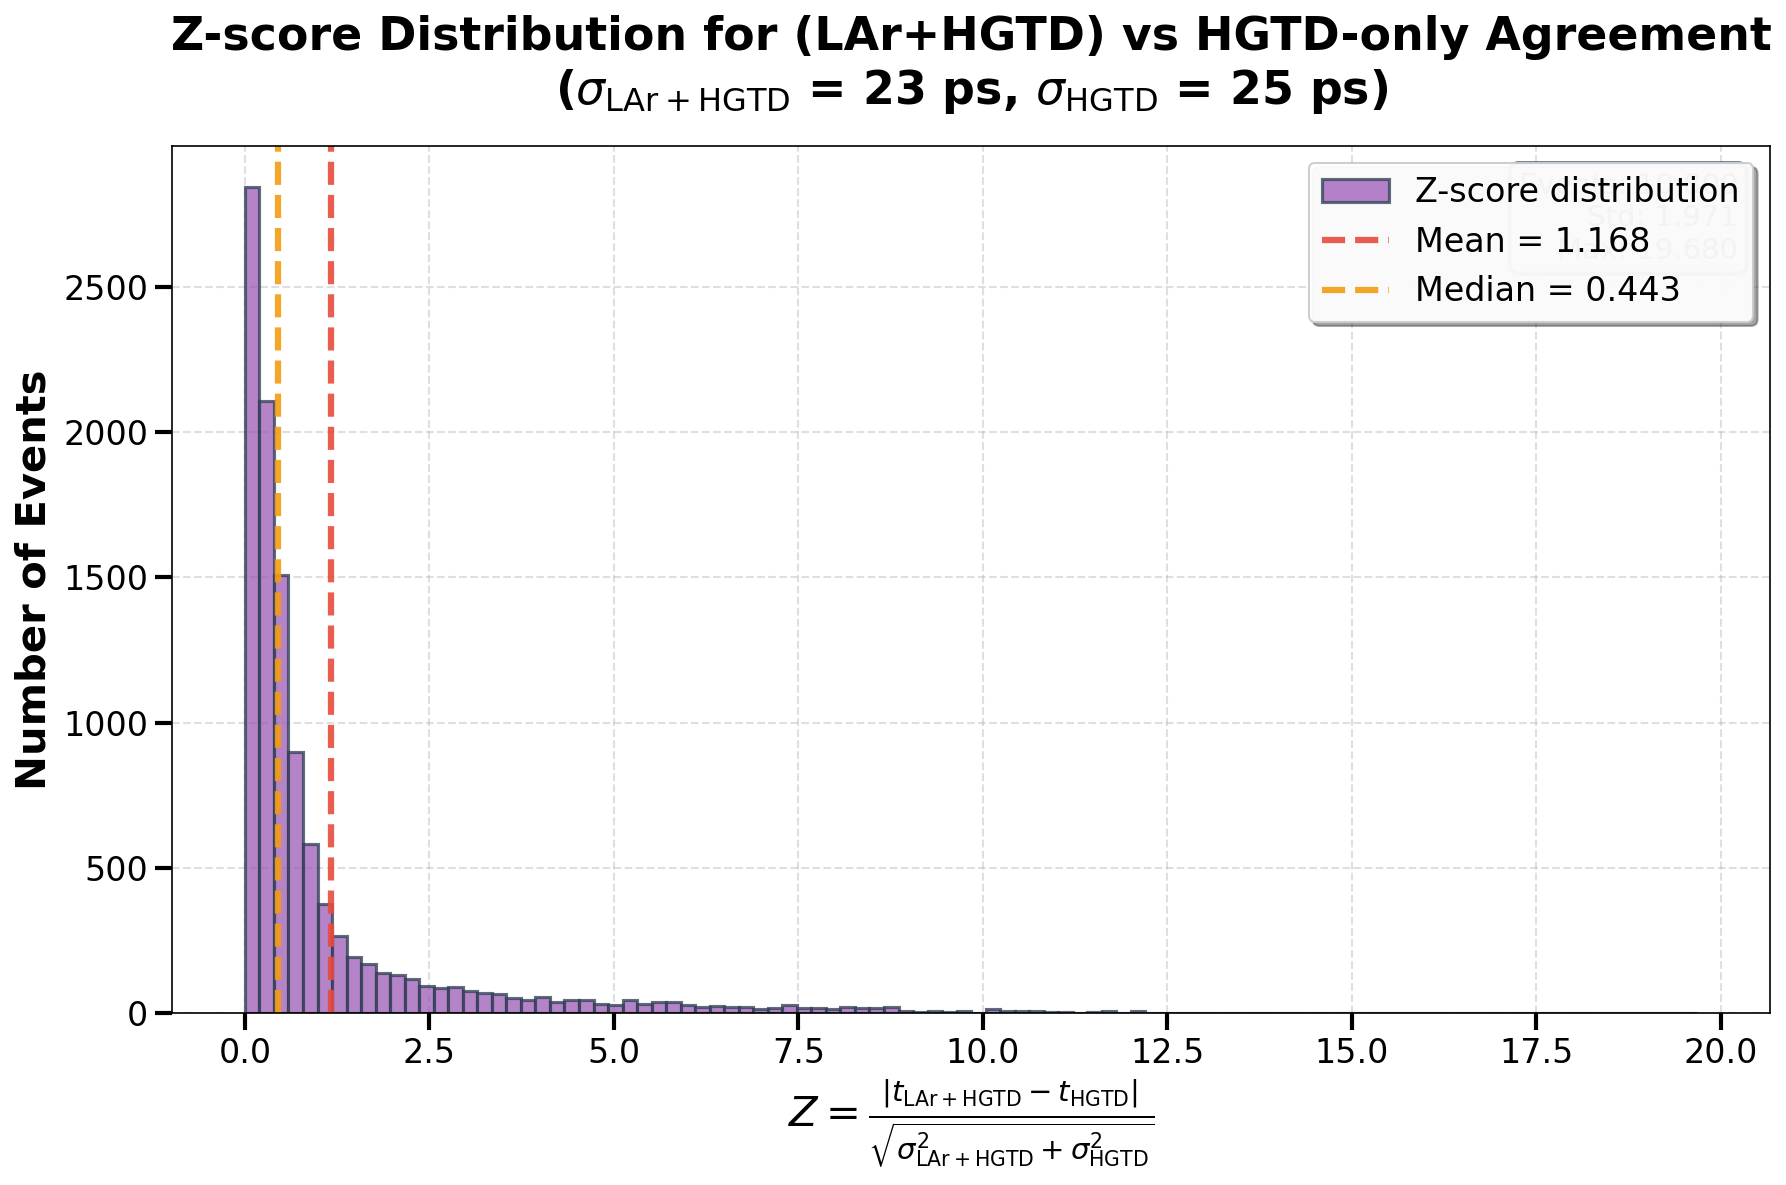

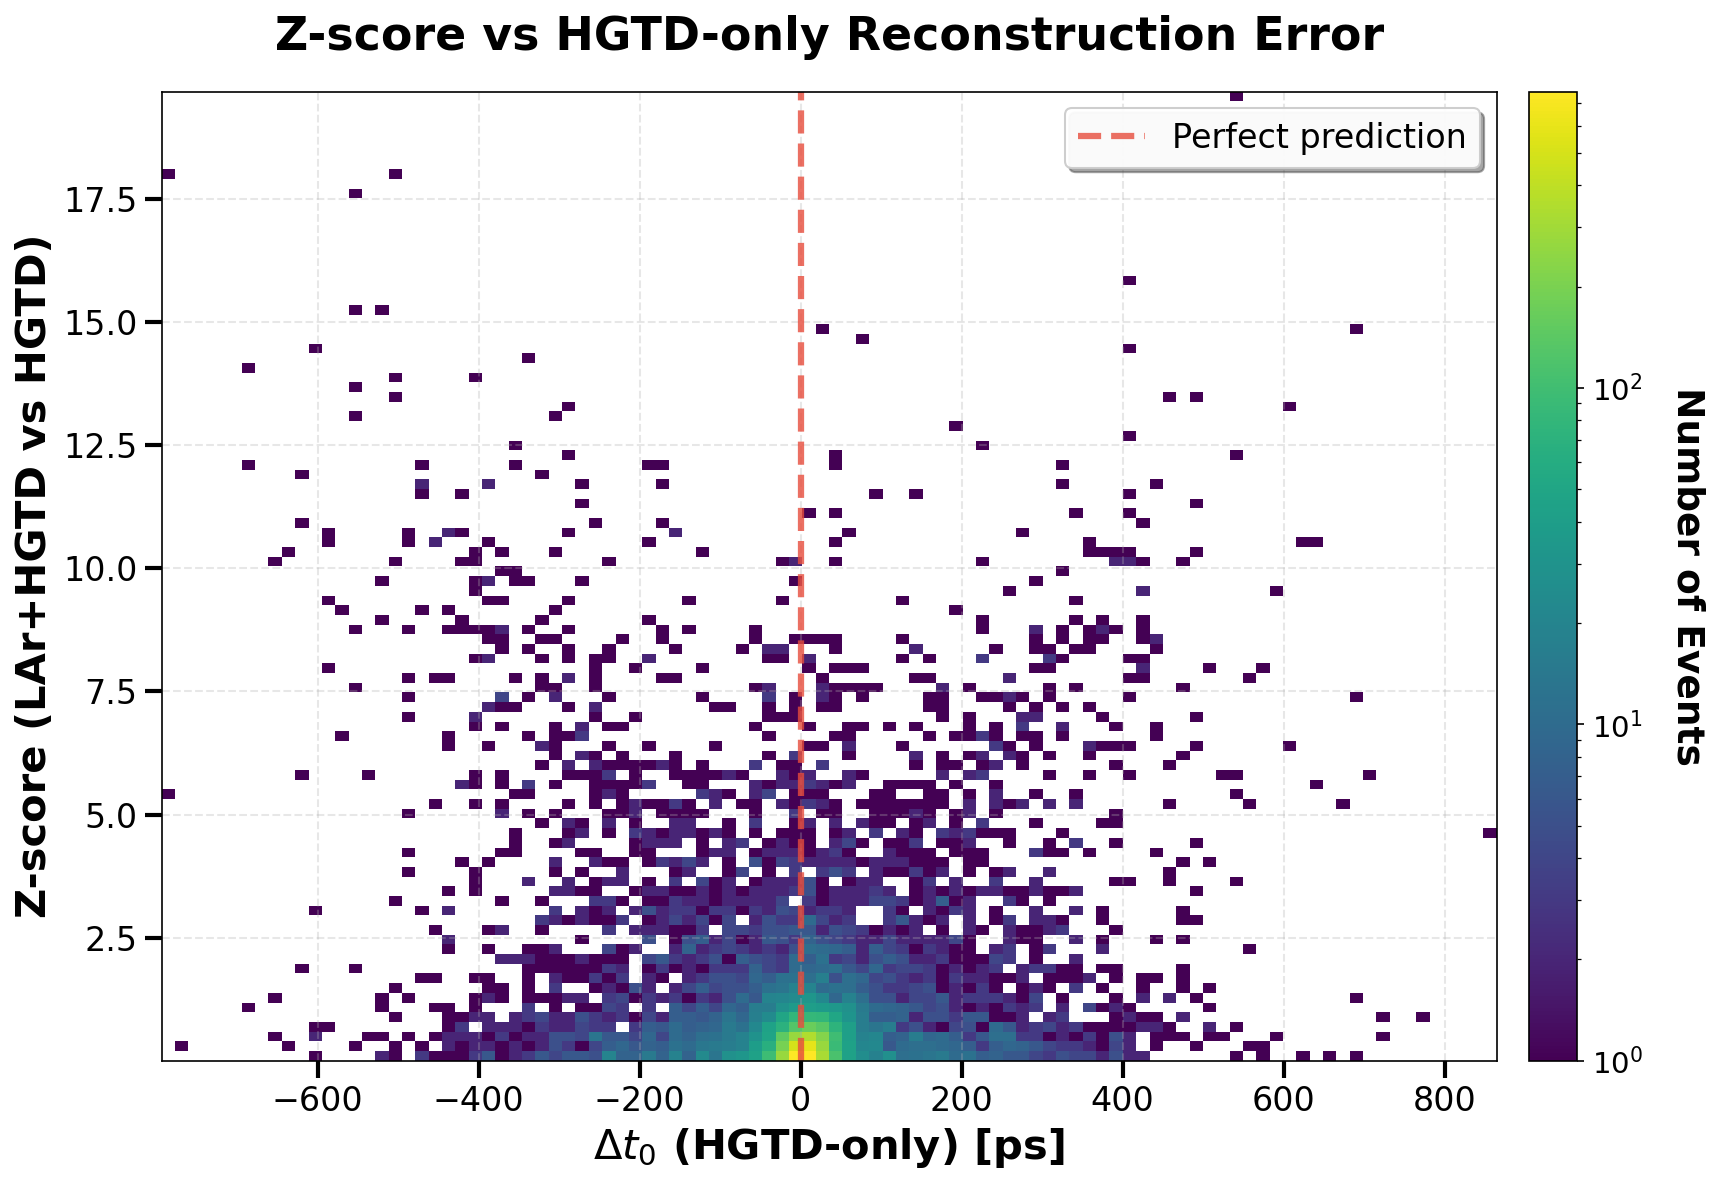

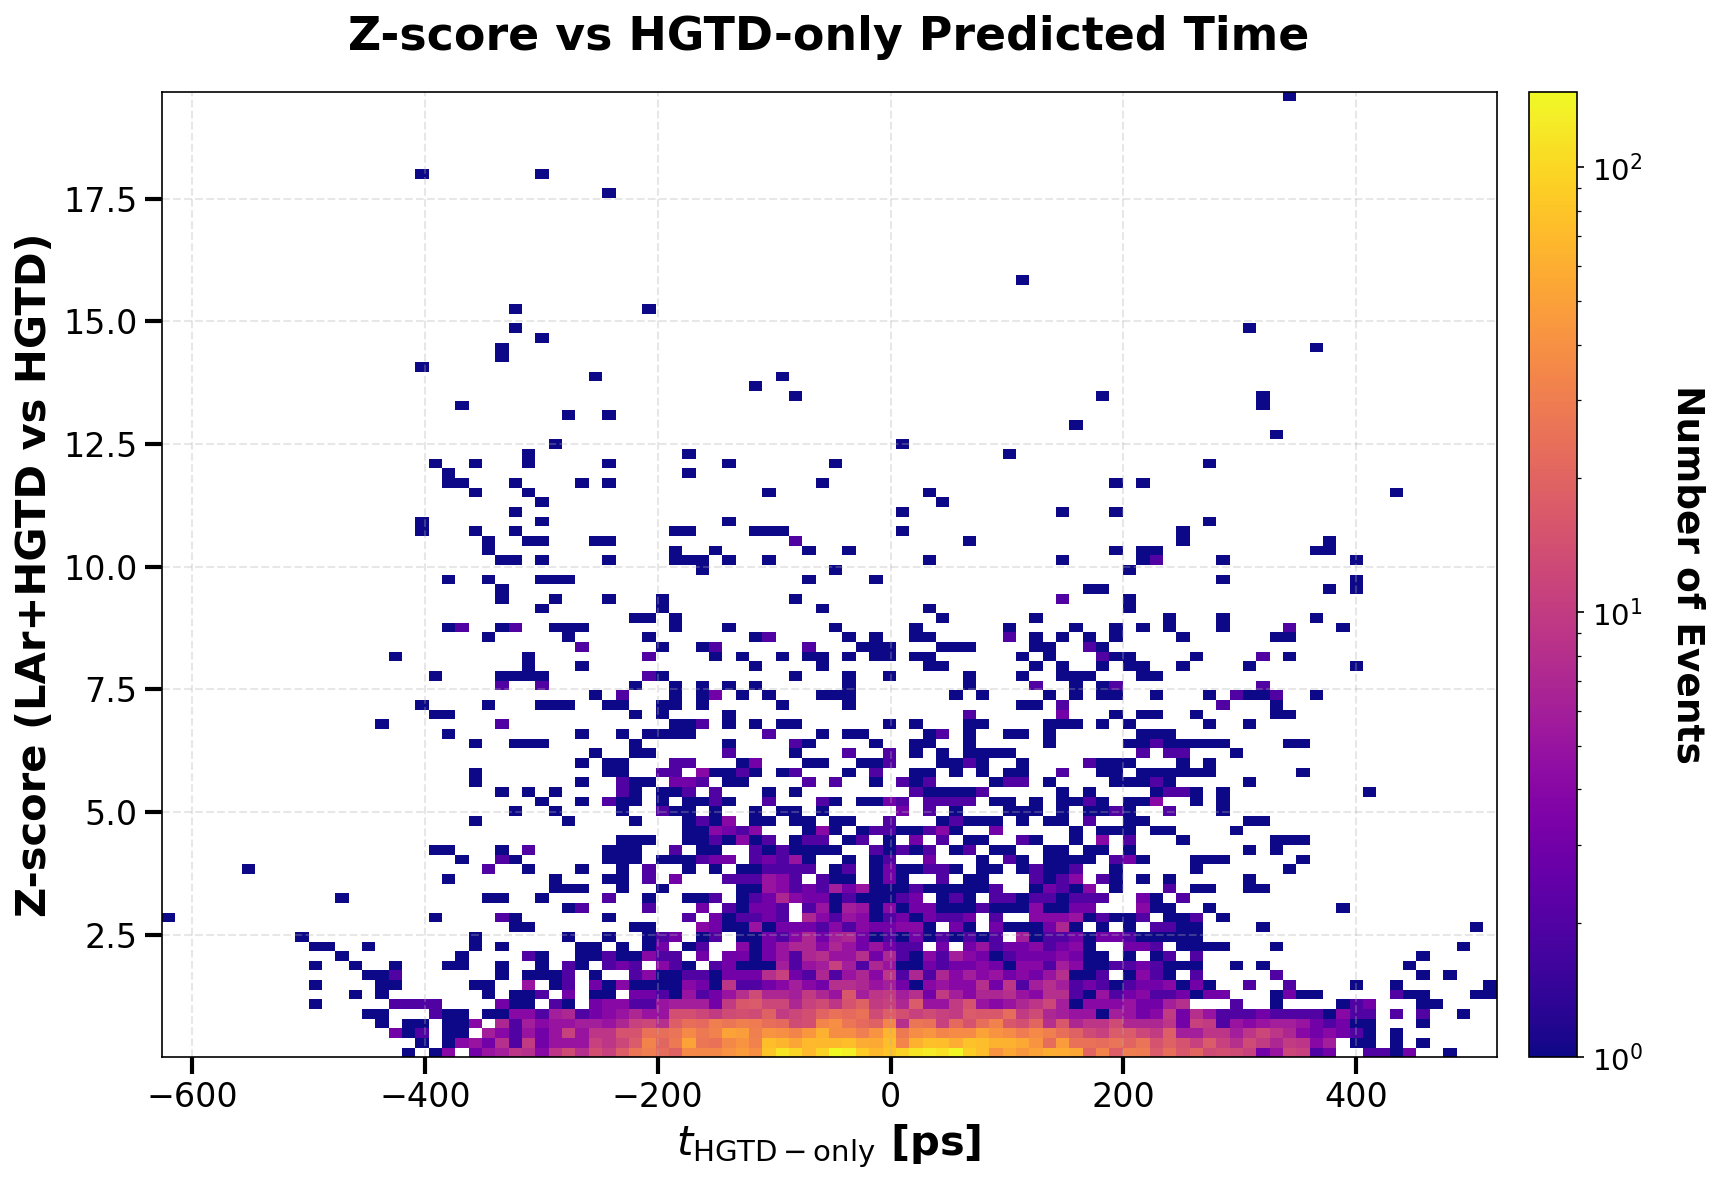

📊 Z-score Statistics (LAr+HGTD vs HGTD-only)
Mean Z-score:        1.1677
Median Z-score:      0.4434
Std Z-score:         1.9706
Max Z-score:         19.6799
Min Z-score:         0.0000

Events with Z > 1:   2818 (26.09%)
Events with Z > 2:   1688 (15.63%)
Events with Z > 3:   1173 (10.86%)

🔝 Top 10 Events with HIGHEST Z-score (LAr+HGTD vs HGTD-only)


,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],Error (LAr+HGTD),Error (HGTD-only),Z_score_combined
4444,4444,201232,2,-197.909454,-329.870514,338.666321,-131.961060,536.575806,19.679880
6342,6342,203283,2,107.633919,215.342728,-398.876587,107.708809,-506.510498,18.080921
725,725,605642,0,491.633484,308.554443,-302.108276,-183.079041,-793.741760,17.976225
9038,9038,205964,2,311.893372,362.705353,-238.849380,50.811981,-550.742737,17.708112
10231,10231,207184,2,-290.919403,-427.688934,110.255974,-136.769531,401.175385,15.835613
9238,9238,206161,2,231.222290,202.711929,-316.620880,-28.510361,-547.843140,15.287725
3205,3205,500765,1,304.958679,306.443268,-209.545197,1.484589,-514.503906,15.189277
10075,10075,206931,2,-384.614594,-202.583694,304.307495,182.030899,688.922119,14.921477
6125,6125,203093,2,-356.705963,179.339828,-326.655060,536.045776,30.050903,14.895093
10338,10338,207218,2,-374.080353,201.422729,-297.938019,575.503052,76.142334,14.699802



🔻 Top 10 Events with LOWEST Z-score (LAr+HGTD vs HGTD-only)


,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],Error (LAr+HGTD),Error (HGTD-only),Z_score_combined
1034,1034,605974,0,101.851654,106.427208,106.425911,4.575554,4.574257,0.000038
3138,3138,500611,1,2.224275,-25.542170,-25.545525,-27.766445,-27.769800,0.000099
3633,3633,501132,1,-18.293205,-45.410580,-45.418976,-27.117374,-27.125771,0.000247
1101,1101,606065,0,150.559509,141.826050,141.845184,-8.733459,-8.714325,0.000563
744,744,605694,0,19.765415,30.367418,30.348194,10.602003,10.582779,0.000566
7422,7422,204316,2,-34.135445,-44.050564,-44.071846,-9.915119,-9.936401,0.000626
3652,3652,501172,1,44.013260,22.342566,22.321201,-21.670694,-21.692059,0.000629
3286,3286,500792,1,-95.365868,-89.263863,-89.285858,6.102005,6.080009,0.000647
811,811,605780,0,35.091442,19.386707,19.411629,-15.704735,-15.679813,0.000734
10649,10649,207606,2,210.593094,-53.085064,-53.110493,-263.678162,-263.703583,0.000749



📊 Summary of Extreme Z-score Events (LAr+HGTD vs HGTD-only)
Category             Mean Z-score    Mean |Error(LAr+HGTD)|    Mean |Error(HGTD)|  
------------------------------------------------------------------------------------------
Top 10 Highest              13.7940                 155.8838            415.2966
Top 10 Lowest                0.0005                  39.5866             39.5859


In [28]:
# Calculate Z-score: |t_LAr+HGTD - t_HGTD| / sqrt(sigma_LAr+HGTD^2 + sigma_HGTD^2)
sigma_lar_hgtd = 23  # ps (LAr+HGTD combined model)
sigma_hgtd = 25  # ps

df['Z_score_combined'] = np.abs(y_pred_lar_hgtd - y_pred_hgtd) / np.sqrt(sigma_lar_hgtd**2 + sigma_hgtd**2)

# ====================================================================
# Figure 1: Z-score Combined Distribution (High Quality, Beautiful)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Plot histogram with beautiful styling
n, bins, patches = ax.hist(df['Z_score_combined'], bins=100, alpha=0.75, 
                           color='#9b59b6', edgecolor='#2c3e50', linewidth=1.5,
                           label='Z-score distribution')

# Add mean and median lines
mean_z = df['Z_score_combined'].mean()
median_z = df['Z_score_combined'].median()

ax.axvline(x=mean_z, color='#e74c3c', linestyle='--', linewidth=3, 
           label=f'Mean = {mean_z:.3f}', alpha=0.9)
ax.axvline(x=median_z, color='#f39c12', linestyle='--', linewidth=3,
           label=f'Median = {median_z:.3f}', alpha=0.9)

# Labels and title with larger fonts
ax.set_xlabel('$Z = \\frac{|t_{\\mathrm{LAr+HGTD}} - t_{\\mathrm{HGTD}}|}{\\sqrt{\\sigma_{\\mathrm{LAr+HGTD}}^2 + \\sigma_{\\mathrm{HGTD}}^2}}$', 
              fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=20, fontweight='bold')
ax.set_title(f'Z-score Distribution for (LAr+HGTD) vs HGTD-only Agreement\n($\\sigma_{{\\mathrm{{LAr+HGTD}}}}$ = {sigma_lar_hgtd} ps, $\\sigma_{{\\mathrm{{HGTD}}}}$ = {sigma_hgtd} ps)', 
             fontsize=22, fontweight='bold', pad=20)

# Enhanced legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid styling
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
ax.tick_params(axis='both', which='minor', labelsize=14, width=1.5, length=5)

# Add statistics box
stats_text = f'Events: {len(df):,}\nStd: {df["Z_score_combined"].std():.3f}\nMax: {df["Z_score_combined"].max():.3f}'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=14, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#34495e', linewidth=2))

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 2: Z-score vs HGTD Error (2D Histogram)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(df['HGTD_error'], df['Z_score_combined'], bins=100, 
              cmap='viridis', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Perfect prediction line
ax.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=3, 
           alpha=0.8, label='Perfect prediction')

# Labels and title
ax.set_xlabel('$\\Delta t_0$ (HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score (LAr+HGTD vs HGTD)', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Reconstruction Error', 
             fontsize=22, fontweight='bold', pad=20)

# Legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 3: Z-score vs HGTD Prediction Value
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(y_pred_hgtd, df['Z_score_combined'], bins=100, 
              cmap='plasma', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Labels and title
ax.set_xlabel('$t_{\\mathrm{HGTD-only}}$ [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score (LAr+HGTD vs HGTD)', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Predicted Time', 
             fontsize=22, fontweight='bold', pad=20)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Print Statistics
# ====================================================================
print("📊 Z-score Statistics (LAr+HGTD vs HGTD-only)")
print("="*60)
print(f"Mean Z-score:        {df['Z_score_combined'].mean():.4f}")
print(f"Median Z-score:      {df['Z_score_combined'].median():.4f}")
print(f"Std Z-score:         {df['Z_score_combined'].std():.4f}")
print(f"Max Z-score:         {df['Z_score_combined'].max():.4f}")
print(f"Min Z-score:         {df['Z_score_combined'].min():.4f}")
print(f"\nEvents with Z > 1:   {(df['Z_score_combined'] > 1).sum()} ({100*(df['Z_score_combined'] > 1).sum()/len(df):.2f}%)")
print(f"Events with Z > 2:   {(df['Z_score_combined'] > 2).sum()} ({100*(df['Z_score_combined'] > 2).sum()/len(df):.2f}%)")
print(f"Events with Z > 3:   {(df['Z_score_combined'] > 3).sum()} ({100*(df['Z_score_combined'] > 3).sum()/len(df):.2f}%)")

# Top 10 highest Z-score_combined events
print("\n" + "="*120)
print("🔝 Top 10 Events with HIGHEST Z-score (LAr+HGTD vs HGTD-only)")
print("="*120)
top_10_high = df.nlargest(40, 'Z_score_combined')
display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr+HGTD [ps]', 'HGTD-only [ps]', 
                    'Error (LAr+HGTD)', 'Error (HGTD-only)', 'Z_score_combined'])
display(top_10_high[display_cols])

# Top 10 lowest Z-score_combined events
print("\n" + "="*120)
print("🔻 Top 10 Events with LOWEST Z-score (LAr+HGTD vs HGTD-only)")
print("="*120)
top_10_low = df.nsmallest(10, 'Z_score_combined')
display(top_10_low[display_cols])

# Summary statistics for these events
print("\n📊 Summary of Extreme Z-score Events (LAr+HGTD vs HGTD-only)")
print("="*90)
print(f"{'Category':<20} {'Mean Z-score':<15} {'Mean |Error(LAr+HGTD)|':<25} {'Mean |Error(HGTD)|':<20}")
print("-"*90)
print(f"{'Top 10 Highest':<20} {top_10_high['Z_score_combined'].mean():>14.4f} "
      f"{top_10_high['Error (LAr+HGTD)'].abs().mean():>24.4f} "
      f"{top_10_high['Error (HGTD-only)'].abs().mean():>19.4f}")
print(f"{'Top 10 Lowest':<20} {top_10_low['Z_score_combined'].mean():>14.4f} "
      f"{top_10_low['Error (LAr+HGTD)'].abs().mean():>24.4f} "
      f"{top_10_low['Error (HGTD-only)'].abs().mean():>19.4f}")

📊 Applying Z-score cut: Z_combined ≤ 1.0
Events before cut: 10800 (100.00%)
Events after cut:  7982 (73.91%)
Events removed:    2818 (26.09%)


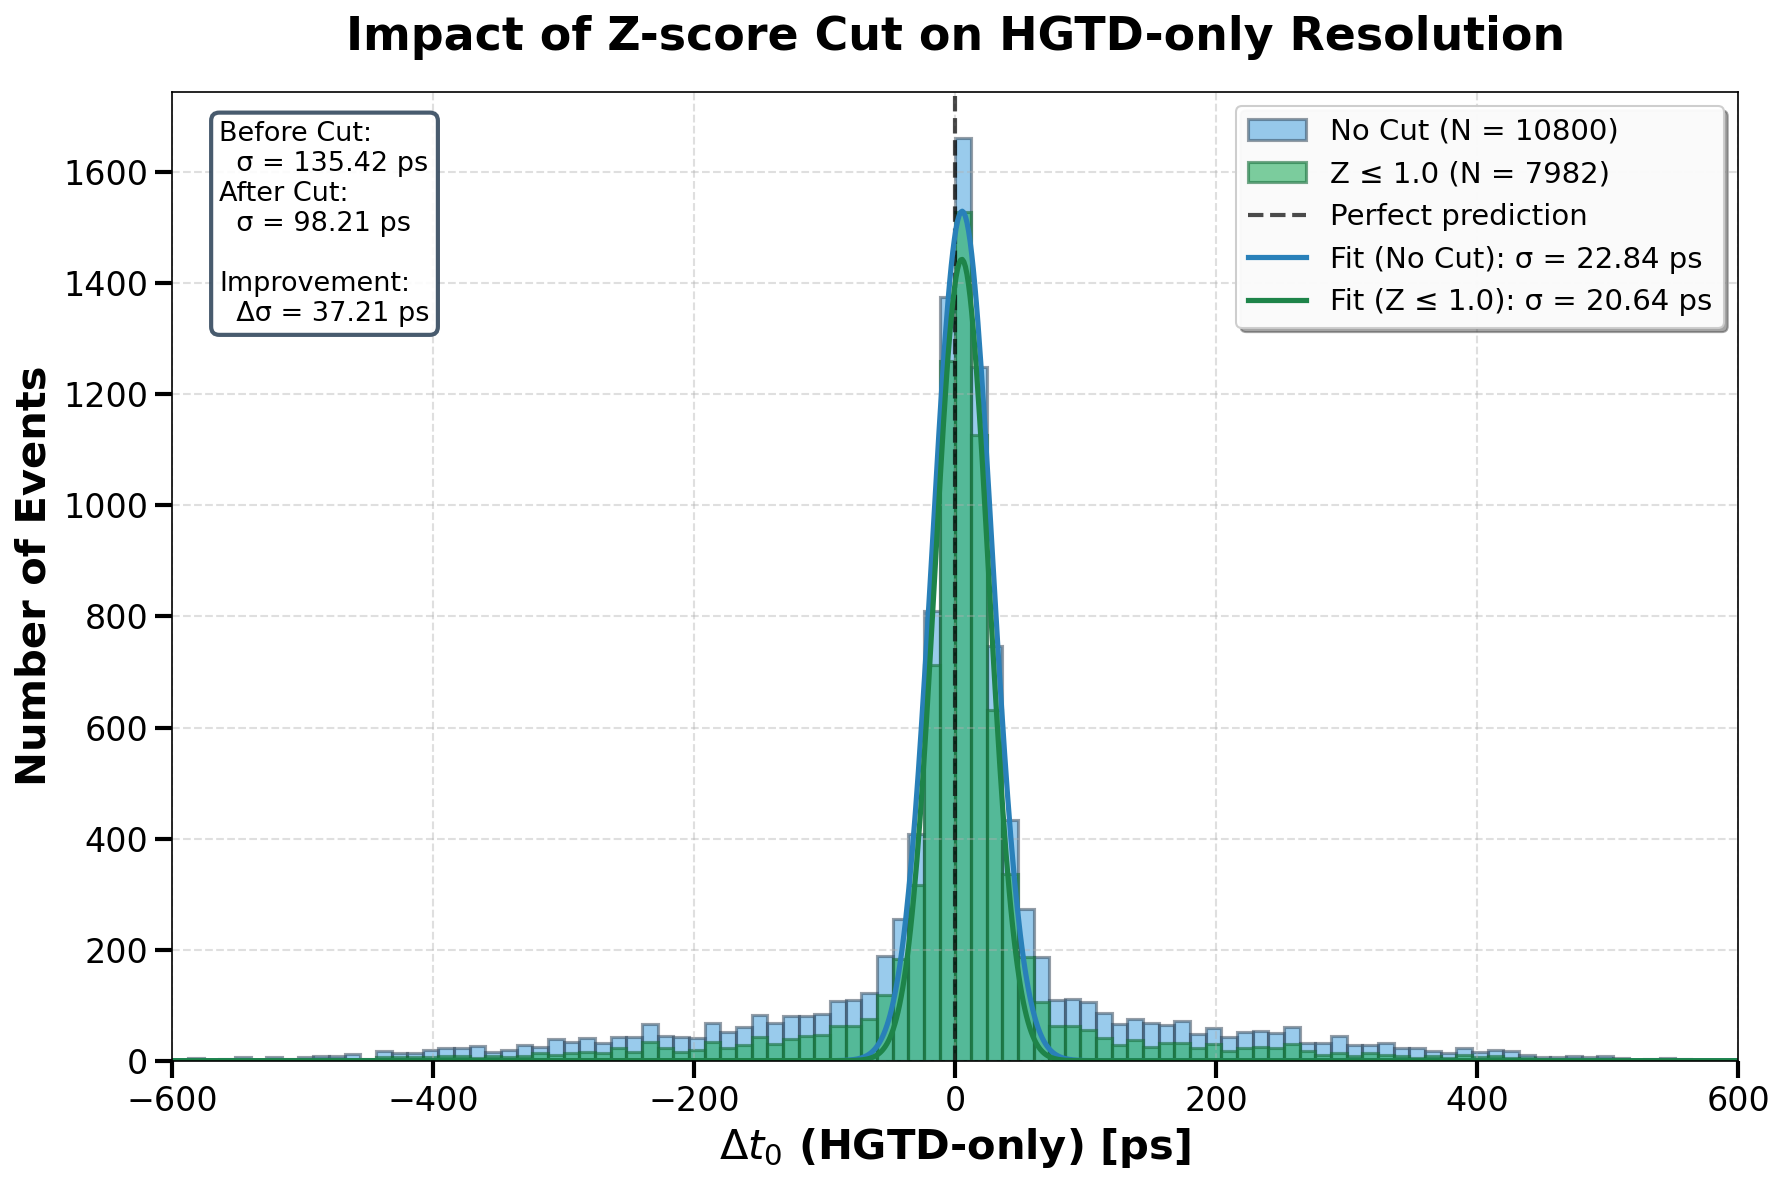


📊 HGTD-only Performance Comparison
Metric               No Cut               Z ≤ 1.0              Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3730              4.0165             -0.6436
Std [ps]                        135.4130             98.2050             37.2080
RMSE [ps]                       135.4552             98.2871             37.1681


In [20]:
from scipy.optimize import curve_fit

# Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Specify Z-score cut threshold
z_cut = 1.0  # Cut for Z_score_combined (LAr+HGTD vs HGTD)

# Apply Z-score cut
df_filtered = df[df['Z_score_combined'] <= z_cut].copy()

print(f"📊 Applying Z-score cut: Z_combined ≤ {z_cut}")
print("="*80)
print(f"Events before cut: {len(df)} (100.00%)")
print(f"Events after cut:  {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")
print(f"Events removed:    {len(df) - len(df_filtered)} ({100*(len(df) - len(df_filtered))/len(df):.2f}%)")
print("="*80)

# Plot comparison on single figure
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Before cut (blue)
data_before = df['Error (HGTD-only)']
n1, bins1, _ = ax.hist(data_before, bins=100, alpha=0.5, color='#3498db', 
                       edgecolor='#2c3e50', linewidth=1.5, label=f'No Cut (N = {len(df)})', 
                       range=(-600, 600))

# After cut (green)
data_after = df_filtered['Error (HGTD-only)']
n2, bins2, _ = ax.hist(data_after, bins=100, alpha=0.6, color='#27ae60', 
                       edgecolor='#196f3d', linewidth=1.5, 
                       label=f'Z ≤ {z_cut} (N = {len(df_filtered)})', range=(-600, 600))

# Zero line
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Perfect prediction')

# Gaussian fits
bin_centers1 = (bins1[:-1] + bins1[1:]) / 2
popt1, _ = curve_fit(gaussian, bin_centers1, n1, p0=[n1.max(), data_before.mean(), data_before.std()])
x_fit = np.linspace(-600, 600, 1000)
ax.plot(x_fit, gaussian(x_fit, *popt1), color='#2980b9', linestyle='-', linewidth=2.5, 
        label=f'Fit (No Cut): σ = {abs(popt1[2]):.2f} ps')

bin_centers2 = (bins2[:-1] + bins2[1:]) / 2
popt2, _ = curve_fit(gaussian, bin_centers2, n2, p0=[n2.max(), data_after.mean(), data_after.std()])
ax.plot(x_fit, gaussian(x_fit, *popt2), color='#1e8449', linestyle='-', linewidth=2.5, 
        label=f'Fit (Z ≤ {z_cut}): σ = {abs(popt2[2]):.2f} ps')

# Labels and styling
ax.set_xlabel('$\\Delta t_0$ (HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=20, fontweight='bold')
ax.set_title(f'Impact of Z-score Cut on HGTD-only Resolution', fontsize=22, fontweight='bold', pad=20)
ax.set_xlim(-600, 600)
ax.legend(fontsize=14, loc='upper right', frameon=True, shadow=True, fancybox=True, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

# Statistics box
stats_text = f'Before Cut:\n  σ = {data_before.std():.2f} ps\n'
stats_text += f'After Cut:\n  σ = {data_after.std():.2f} ps\n\n'
stats_text += f'Improvement:\n  Δσ = {data_before.std() - data_after.std():.2f} ps'
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', 
        alpha=0.9, edgecolor='#34495e', linewidth=2))

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'Z ≤ ' + str(z_cut):<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), 
                     ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before = func(data_before)
    after = func(data_after)
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

📊 Applying Z-score cuts: Z₁ ≤ 1.0 AND Z₂ ≤ 1.0
Events before cut: 10800
Events after cut:  4055 (37.55%)
Events removed:    6745 (62.45%)


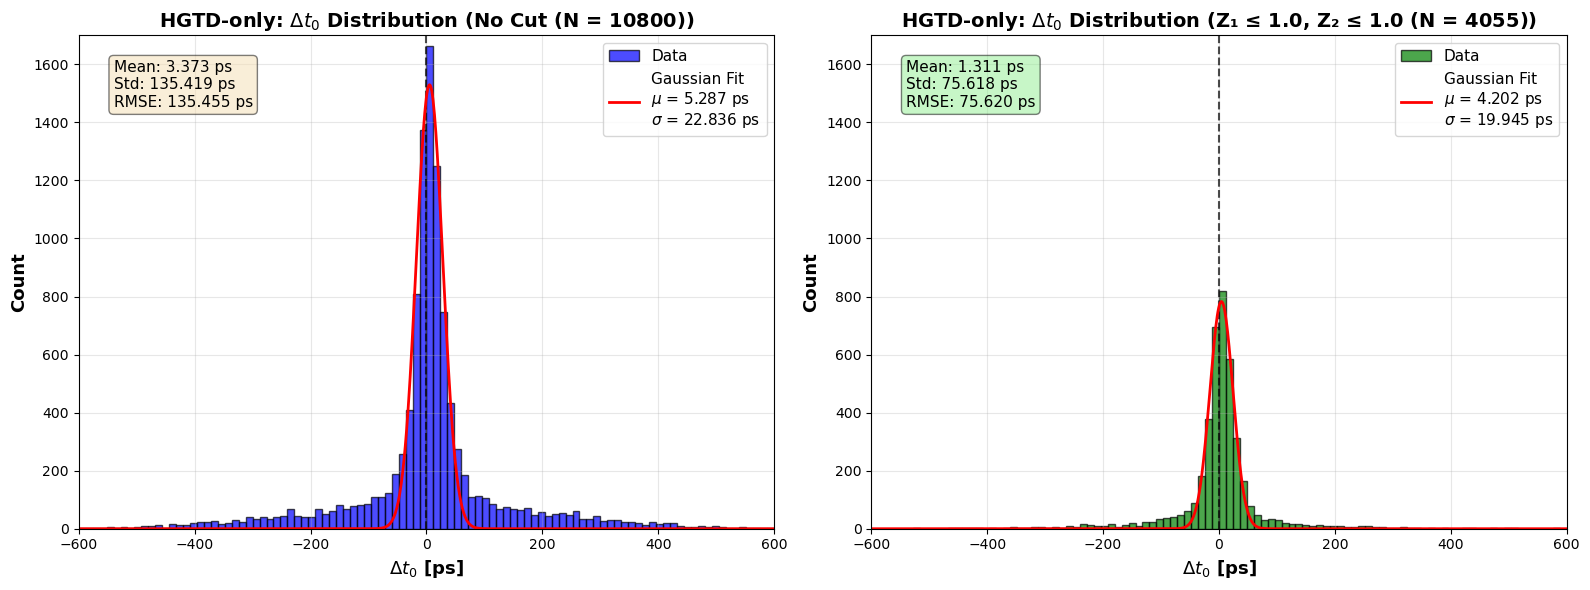


📊 HGTD-only Performance Comparison
Metric               No Cut               With Cuts            Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3730              1.3105              2.0624
Std [ps]                        135.4130             75.6083             59.8047
RMSE [ps]                       135.4552             75.6197             59.8355

📊 Cut Breakdown
Events passing Z₁ ≤ 1.0:           4820 (44.63%)
Events passing Z₂ ≤ 1.0:           7982 (73.91%)
Events passing both cuts:      4055 (37.55%)


In [21]:
from scipy.optimize import curve_fit

# Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Specify Z-score cut thresholds
z_cut_1 = 1.0  # Cut for Z_score (LAr vs HGTD)
z_cut_2 = 1.0  # Cut for Z_score_combined (LAr+HGTD vs HGTD)

# Apply both Z-score cuts
df_filtered = df[(df['Z_score'] <= z_cut_1) & (df['Z_score_combined'] <= z_cut_2)].copy()

print(f"📊 Applying Z-score cuts: Z₁ ≤ {z_cut_1} AND Z₂ ≤ {z_cut_2}")
print("="*80)
print(f"Events before cut: {len(df)}")
print(f"Events after cut:  {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")
print(f"Events removed:    {len(df) - len(df_filtered)} ({100*(len(df) - len(df_filtered))/len(df):.2f}%)")
print("="*80)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (data, title, color) in enumerate([
    (df['Error (HGTD-only)'], f'No Cut (N = {len(df)})', 'blue'),
    (df_filtered['Error (HGTD-only)'], f'Z₁ ≤ {z_cut_1}, Z₂ ≤ {z_cut_2} (N = {len(df_filtered)})', 'green')
]):
    # Histogram
    n, bins, _ = axes[idx].hist(data, bins=100, alpha=0.7, color=color, edgecolor='black', label='Data', range=(-600, 600))
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Gaussian fit
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, _ = curve_fit(gaussian, bin_centers, n, p0=[n.max(), data.mean(), data.std()])
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    axes[idx].plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2, 
                   label=f'Gaussian Fit\n$\\mu$ = {popt[1]:.3f} ps\n$\\sigma$ = {abs(popt[2]):.3f} ps')
    
    # Labels and text
    axes[idx].set_xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=13, fontweight='bold')
    axes[idx].set_title(f'HGTD-only: $\\Delta t_0$ Distribution ({title})', fontsize=14, fontweight='bold')
    axes[idx].set_xlim(-600, 600)
    axes[idx].set_ylim(0, 1700)
    axes[idx].legend(fontsize=11, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0.05, 0.95, f'Mean: {data.mean():.3f} ps\nStd: {data.std():.3f} ps\nRMSE: {np.sqrt((data**2).mean()):.3f} ps',
                   transform=axes[idx].transAxes, fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat' if idx==0 else 'lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'With Cuts':<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before, after = func(df['Error (HGTD-only)']), func(df_filtered['Error (HGTD-only)'])
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

# Print cut breakdown
print(f"\n📊 Cut Breakdown")
print("="*80)
print(f"Events passing Z₁ ≤ {z_cut_1}:           {(df['Z_score'] <= z_cut_1).sum()} ({100*(df['Z_score'] <= z_cut_1).sum()/len(df):.2f}%)")
print(f"Events passing Z₂ ≤ {z_cut_2}:           {(df['Z_score_combined'] <= z_cut_2).sum()} ({100*(df['Z_score_combined'] <= z_cut_2).sum()/len(df):.2f}%)")
print(f"Events passing both cuts:      {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")

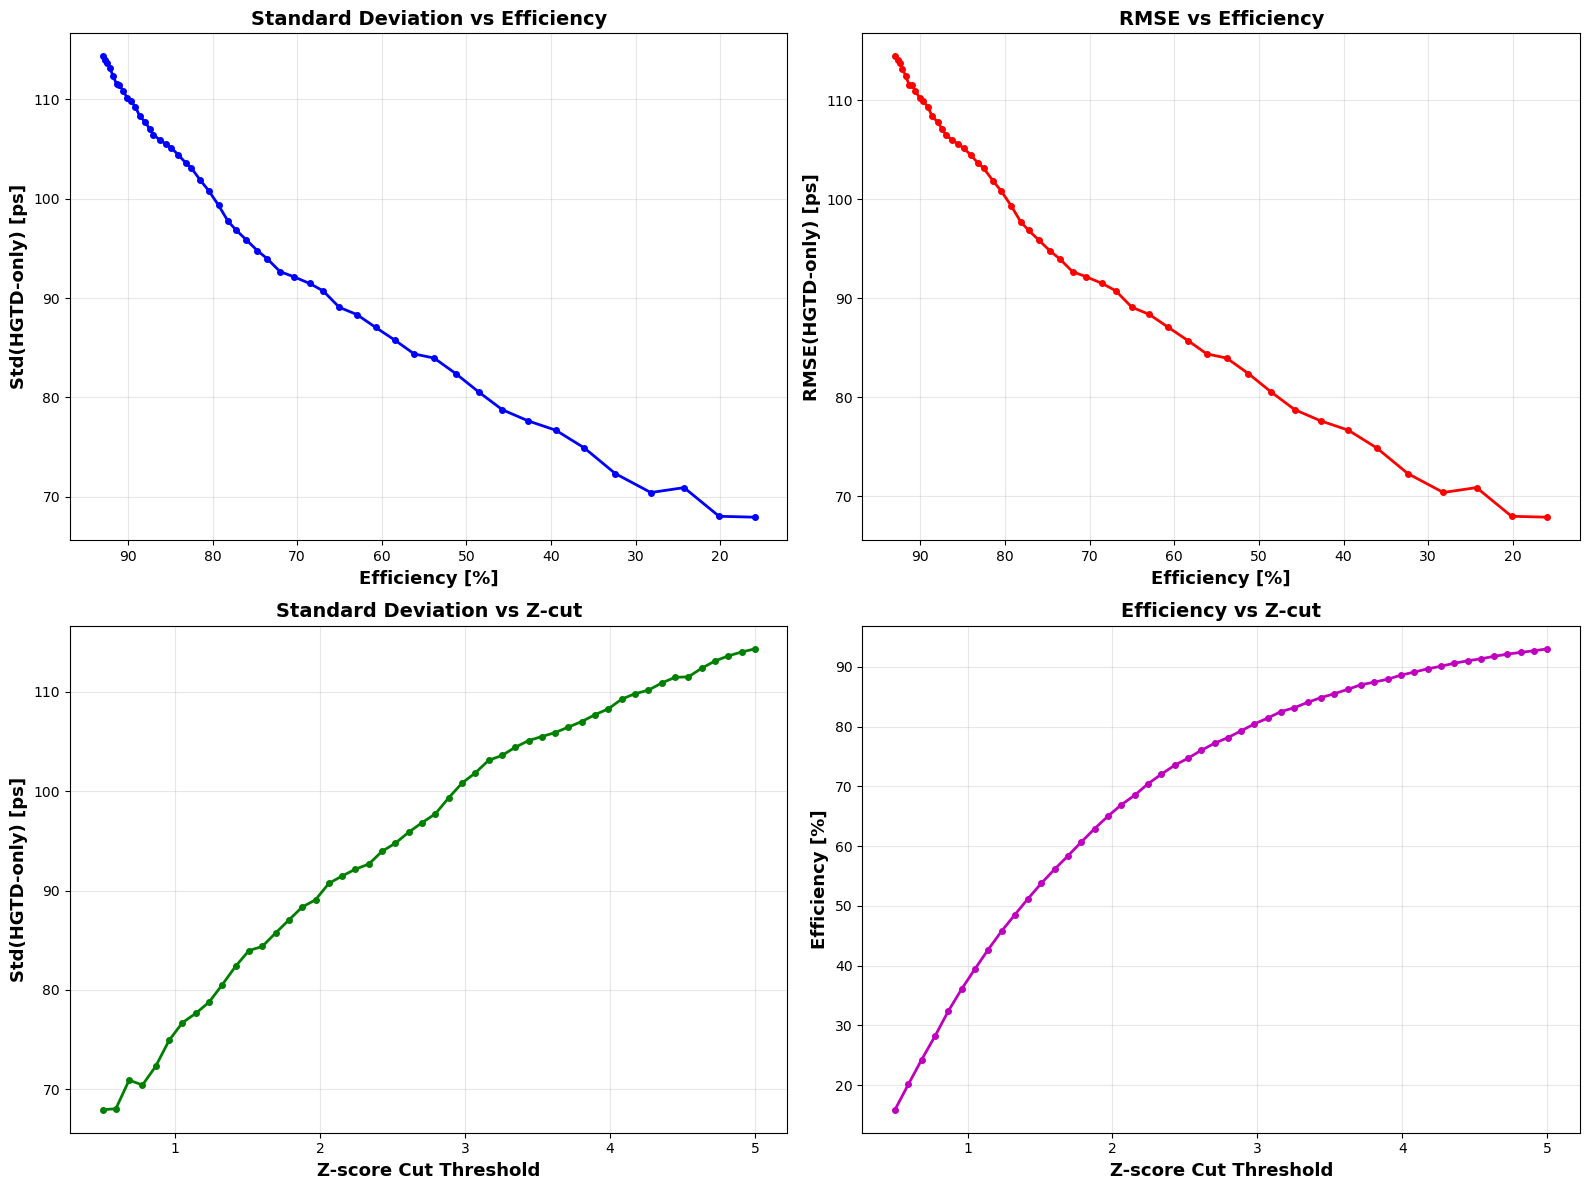


📊 Scan Results Summary
Z-cut      Efficiency [%]  Std [ps]        RMSE [ps]      
--------------------------------------------------------------------------------
0.50       15.92           67.925          67.911         
1.60       56.17           84.364          84.398         
2.80       78.16           97.721          97.747         
3.90       87.93           107.711         107.772        
5.00       93.00           114.339         114.434        


In [22]:
# Scan over different Z-score cut values
z_scan_values = np.linspace(0.5, 5.0, 50)  # Scan from 0.5 to 5.0

efficiencies = []
std_values = []
mean_values = []
rmse_values = []

for z_threshold in z_scan_values:
    # Apply symmetric cuts on both Z-scores
    df_scan = df[(df['Z_score'] <= z_threshold) & (df['Z_score_combined'] <= z_threshold)]
    
    # Calculate efficiency
    efficiency = len(df_scan) / len(df) * 100
    efficiencies.append(efficiency)
    
    # Calculate performance metrics
    if len(df_scan) > 0:
        std_values.append(df_scan['Error (HGTD-only)'].std())
        mean_values.append(df_scan['Error (HGTD-only)'].mean())
        rmse_values.append(np.sqrt((df_scan['Error (HGTD-only)']**2).mean()))
    else:
        std_values.append(np.nan)
        mean_values.append(np.nan)
        rmse_values.append(np.nan)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Std vs Efficiency
axes[0, 0].plot(efficiencies, std_values, 'b-', linewidth=2, marker='o', markersize=4)
axes[0, 0].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Standard Deviation vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_xaxis()  # Higher efficiency on the right

# Plot 2: RMSE vs Efficiency
axes[0, 1].plot(efficiencies, rmse_values, 'r-', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('RMSE(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 1].set_title('RMSE vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_xaxis()

# Plot 3: Std vs Z-cut threshold
axes[1, 0].plot(z_scan_values, std_values, 'g-', linewidth=2, marker='o', markersize=4)
axes[1, 0].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Standard Deviation vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Efficiency vs Z-cut threshold
axes[1, 1].plot(z_scan_values, efficiencies, 'm-', linewidth=2, marker='o', markersize=4)
axes[1, 1].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Efficiency vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some key points
print("\n📊 Scan Results Summary")
print("="*80)
print(f"{'Z-cut':<10} {'Efficiency [%]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*80)
for i in [0, len(z_scan_values)//4, len(z_scan_values)//2, 3*len(z_scan_values)//4, -1]:
    print(f"{z_scan_values[i]:<10.2f} {efficiencies[i]:<15.2f} {std_values[i]:<15.3f} {rmse_values[i]:<15.3f}")

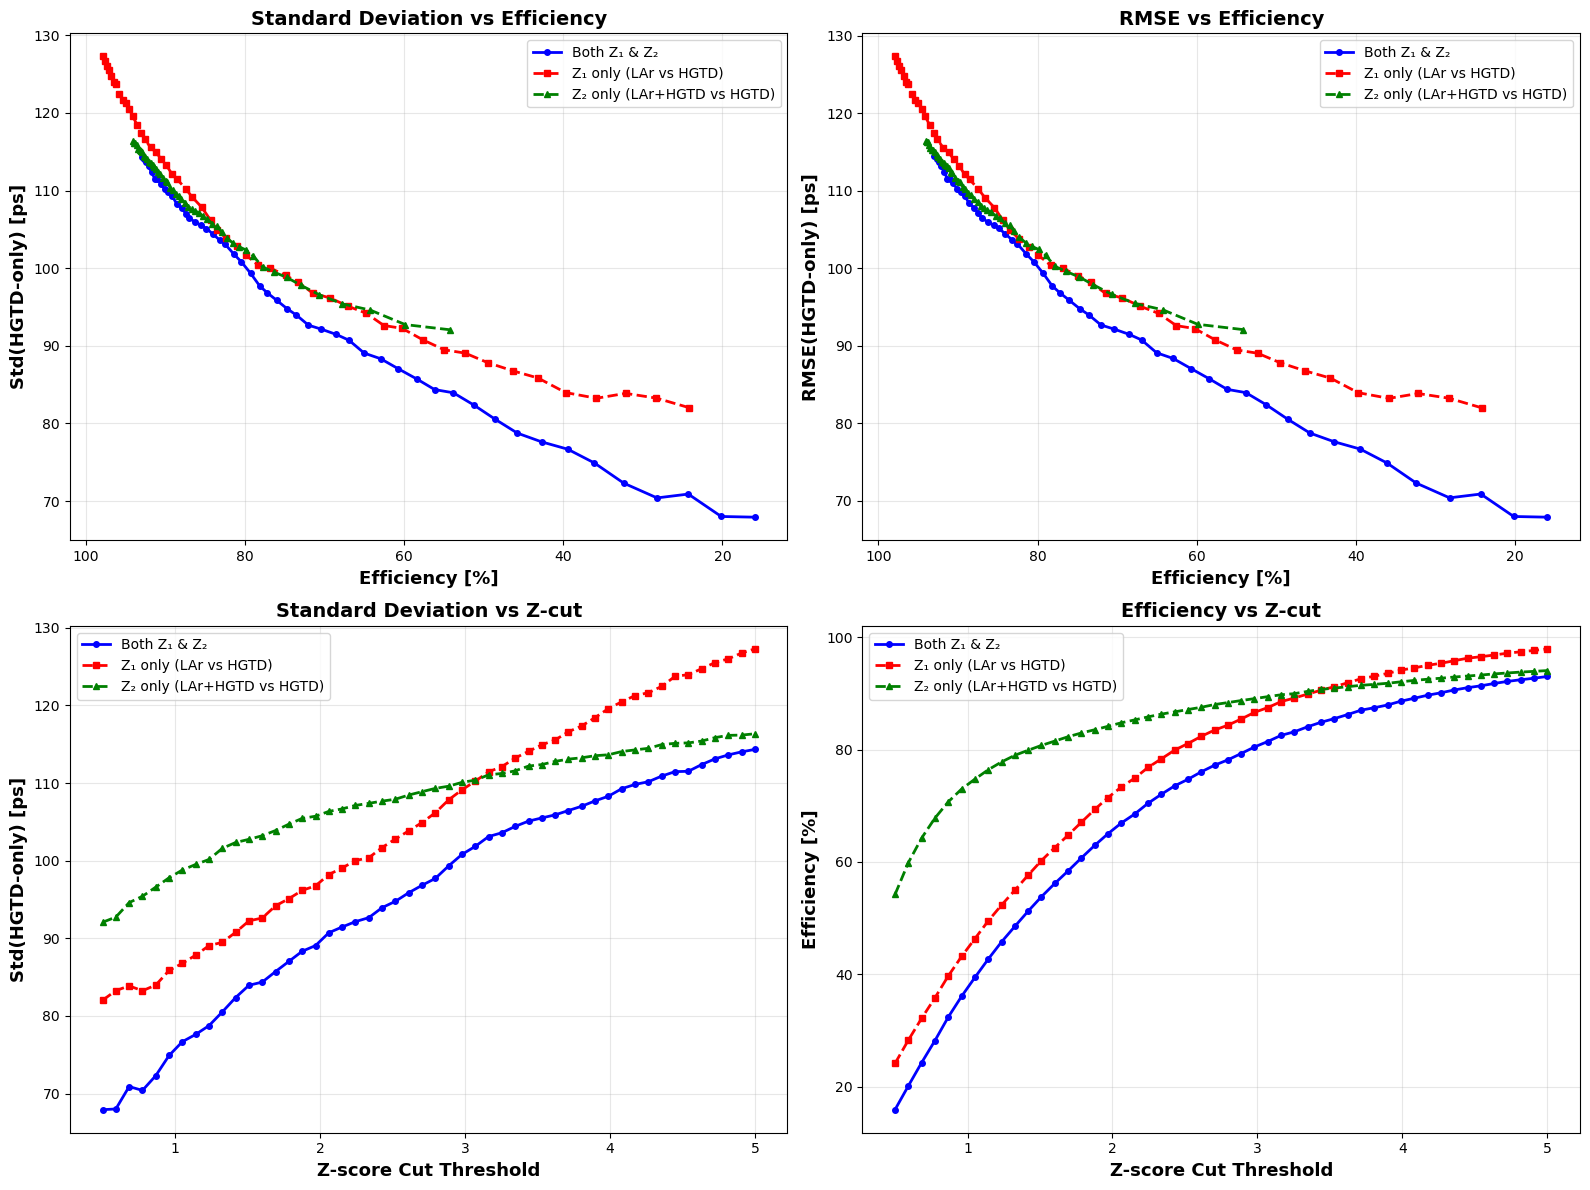


📊 Scan Results Comparison
Z-cut    Strategy             Efficiency [%]  Std [ps]        RMSE [ps]      
----------------------------------------------------------------------------------------------------
0.50     Both Z₁ & Z₂         15.92           67.925          67.911         
         Z₁ only              24.14           82.020          82.005         
         Z₂ only              54.20           92.066          92.109         
----------------------------------------------------------------------------------------------------
1.60     Both Z₁ & Z₂         56.17           84.364          84.398         
         Z₁ only              62.55           92.618          92.612         
         Z₂ only              81.50           103.220         103.322        
----------------------------------------------------------------------------------------------------
2.80     Both Z₁ & Z₂         78.16           97.721          97.747         
         Z₁ only              84.32           

In [23]:
# Scan over different Z-score cut values
z_scan_values = np.linspace(0.5, 5.0, 50)  # Scan from 0.5 to 5.0

# Storage for both Z-scores combined
efficiencies_both = []
std_values_both = []
mean_values_both = []
rmse_values_both = []

# Storage for Z_score only (LAr vs HGTD)
efficiencies_z1 = []
std_values_z1 = []
mean_values_z1 = []
rmse_values_z1 = []

# Storage for Z_score_combined only (LAr+HGTD vs HGTD)
efficiencies_z2 = []
std_values_z2 = []
mean_values_z2 = []
rmse_values_z2 = []

for z_threshold in z_scan_values:
    # Apply cuts with both Z-scores
    df_both = df[(df['Z_score'] <= z_threshold) & (df['Z_score_combined'] <= z_threshold)]
    efficiencies_both.append(len(df_both) / len(df) * 100)
    std_values_both.append(df_both['Error (HGTD-only)'].std() if len(df_both) > 0 else np.nan)
    mean_values_both.append(df_both['Error (HGTD-only)'].mean() if len(df_both) > 0 else np.nan)
    rmse_values_both.append(np.sqrt((df_both['Error (HGTD-only)']**2).mean()) if len(df_both) > 0 else np.nan)
    
    # Apply cut with Z_score only
    df_z1 = df[df['Z_score'] <= z_threshold]
    efficiencies_z1.append(len(df_z1) / len(df) * 100)
    std_values_z1.append(df_z1['Error (HGTD-only)'].std() if len(df_z1) > 0 else np.nan)
    mean_values_z1.append(df_z1['Error (HGTD-only)'].mean() if len(df_z1) > 0 else np.nan)
    rmse_values_z1.append(np.sqrt((df_z1['Error (HGTD-only)']**2).mean()) if len(df_z1) > 0 else np.nan)
    
    # Apply cut with Z_score_combined only
    df_z2 = df[df['Z_score_combined'] <= z_threshold]
    efficiencies_z2.append(len(df_z2) / len(df) * 100)
    std_values_z2.append(df_z2['Error (HGTD-only)'].std() if len(df_z2) > 0 else np.nan)
    mean_values_z2.append(df_z2['Error (HGTD-only)'].mean() if len(df_z2) > 0 else np.nan)
    rmse_values_z2.append(np.sqrt((df_z2['Error (HGTD-only)']**2).mean()) if len(df_z2) > 0 else np.nan)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Std vs Efficiency
axes[0, 0].plot(efficiencies_both, std_values_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[0, 0].plot(efficiencies_z1, std_values_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[0, 0].plot(efficiencies_z2, std_values_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[0, 0].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Standard Deviation vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_xaxis()

# Plot 2: RMSE vs Efficiency
axes[0, 1].plot(efficiencies_both, rmse_values_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[0, 1].plot(efficiencies_z1, rmse_values_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[0, 1].plot(efficiencies_z2, rmse_values_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[0, 1].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('RMSE(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 1].set_title('RMSE vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_xaxis()

# Plot 3: Std vs Z-cut threshold
axes[1, 0].plot(z_scan_values, std_values_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[1, 0].plot(z_scan_values, std_values_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[1, 0].plot(z_scan_values, std_values_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[1, 0].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Standard Deviation vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Efficiency vs Z-cut threshold
axes[1, 1].plot(z_scan_values, efficiencies_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[1, 1].plot(z_scan_values, efficiencies_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[1, 1].plot(z_scan_values, efficiencies_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[1, 1].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Efficiency vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison at key points
print("\n📊 Scan Results Comparison")
print("="*100)
print(f"{'Z-cut':<8} {'Strategy':<20} {'Efficiency [%]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*100)
for i in [0, len(z_scan_values)//4, len(z_scan_values)//2, 3*len(z_scan_values)//4, -1]:
    print(f"{z_scan_values[i]:<8.2f} {'Both Z₁ & Z₂':<20} {efficiencies_both[i]:<15.2f} {std_values_both[i]:<15.3f} {rmse_values_both[i]:<15.3f}")
    print(f"{'':8} {'Z₁ only':<20} {efficiencies_z1[i]:<15.2f} {std_values_z1[i]:<15.3f} {rmse_values_z1[i]:<15.3f}")
    print(f"{'':8} {'Z₂ only':<20} {efficiencies_z2[i]:<15.2f} {std_values_z2[i]:<15.3f} {rmse_values_z2[i]:<15.3f}")
    print("-"*100)

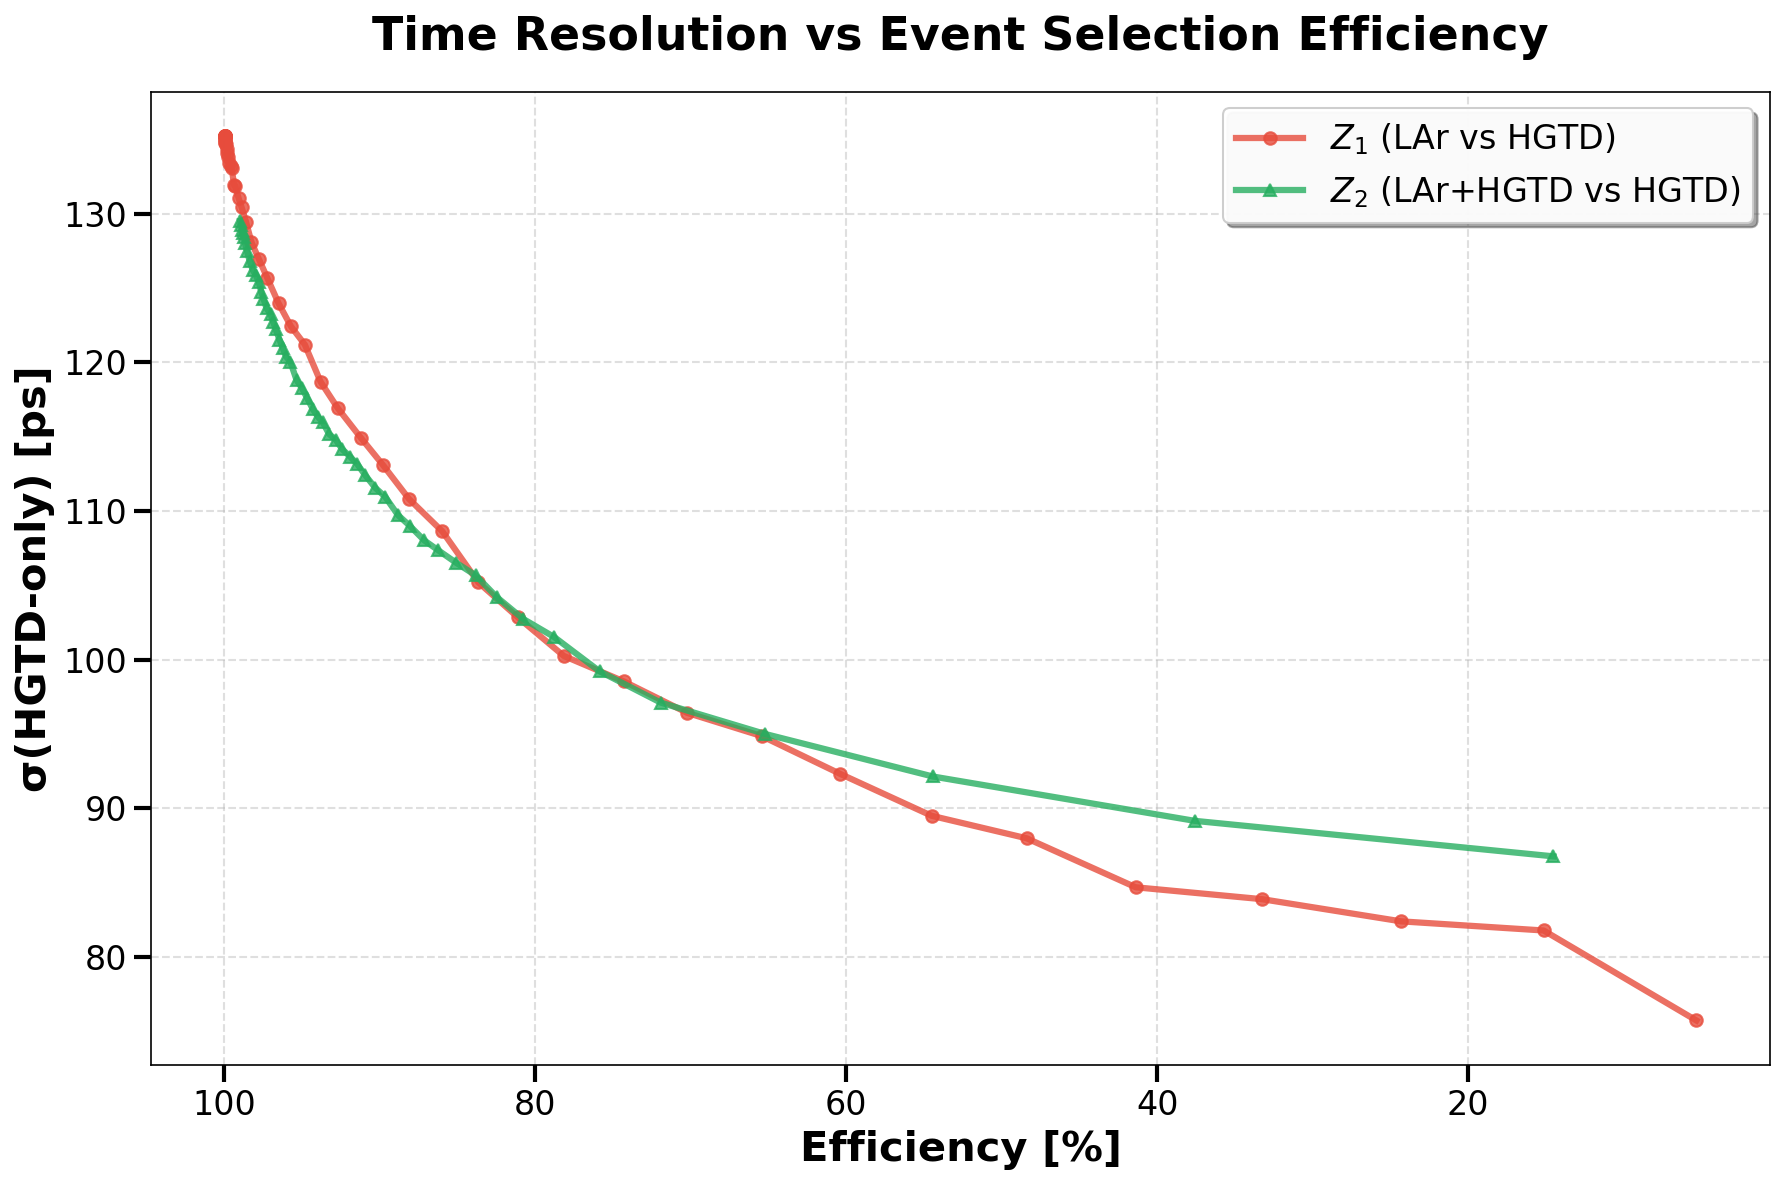

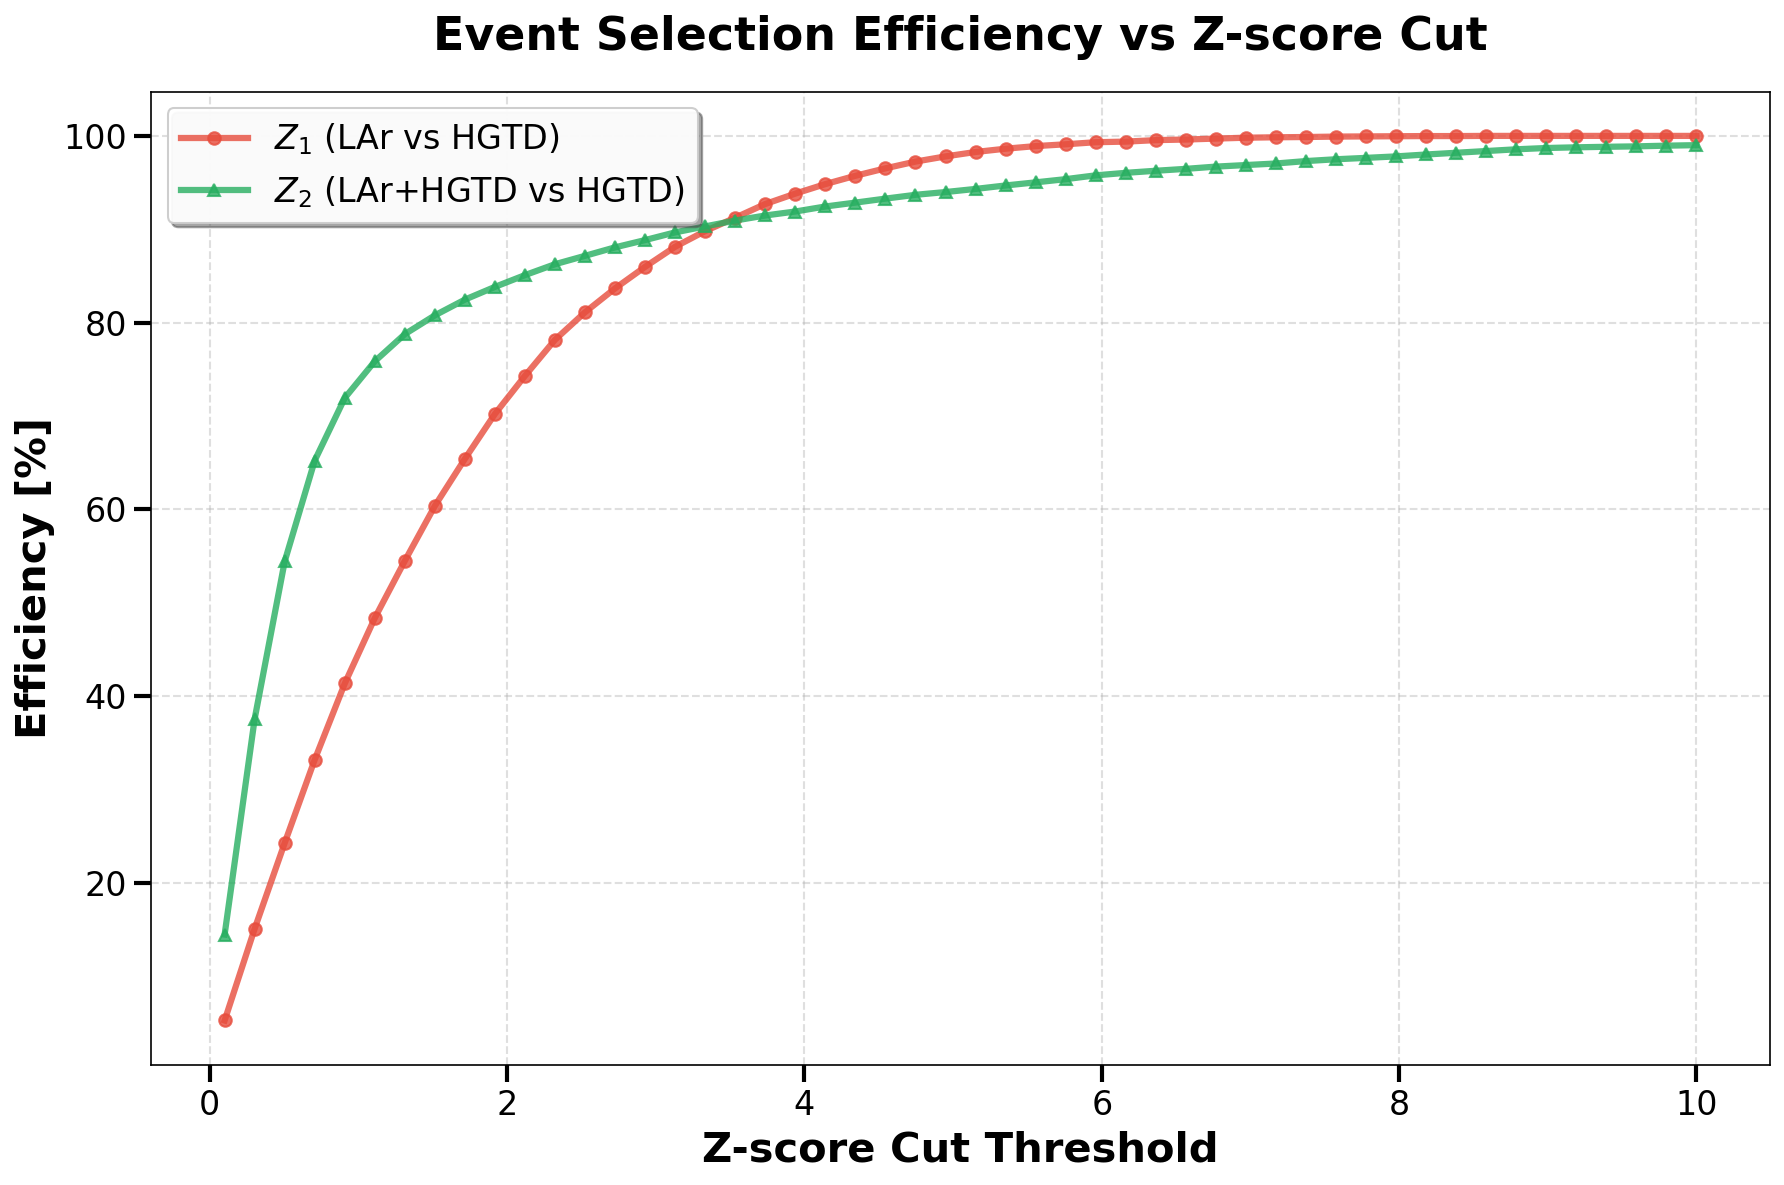


📊 Z-score Cut Performance Comparison
Z-cut      Strategy                  Efficiency [%]     σ [ps]          RMSE [ps]      
------------------------------------------------------------------------------------------
0.10       Z₁ (LAr vs HGTD)          5.31               75.702          75.793         
           Z₂ (LAr+HGTD vs HGTD)     14.51              86.749          86.731         
------------------------------------------------------------------------------------------
2.52       Z₁ (LAr vs HGTD)          81.11              102.831         102.828        
           Z₂ (LAr+HGTD vs HGTD)     87.15              108.024         108.129        
------------------------------------------------------------------------------------------
5.15       Z₁ (LAr vs HGTD)          98.26              128.103         128.165        
           Z₂ (LAr+HGTD vs HGTD)     94.31              116.843         116.929        
-------------------------------------------------------------------------

In [24]:
# Scan over different Z-score cut values
z_scan_values = np.linspace(0.1, 10.0, 50)  # Scan from 0.5 to 5.0

# Storage for Z_score only (LAr vs HGTD)
efficiencies_z1 = []
std_values_z1 = []
rmse_values_z1 = []

# Storage for Z_score_combined only (LAr+HGTD vs HGTD)
efficiencies_z2 = []
std_values_z2 = []
rmse_values_z2 = []

for z_threshold in z_scan_values:
    # Apply cut with Z_score only
    df_z1 = df[df['Z_score'] <= z_threshold]
    efficiencies_z1.append(len(df_z1) / len(df) * 100)
    std_values_z1.append(df_z1['Error (HGTD-only)'].std() if len(df_z1) > 0 else np.nan)
    rmse_values_z1.append(np.sqrt((df_z1['Error (HGTD-only)']**2).mean()) if len(df_z1) > 0 else np.nan)
    
    # Apply cut with Z_score_combined only
    df_z2 = df[df['Z_score_combined'] <= z_threshold]
    efficiencies_z2.append(len(df_z2) / len(df) * 100)
    std_values_z2.append(df_z2['Error (HGTD-only)'].std() if len(df_z2) > 0 else np.nan)
    rmse_values_z2.append(np.sqrt((df_z2['Error (HGTD-only)']**2).mean()) if len(df_z2) > 0 else np.nan)

# ====================================================================
# Figure 1: Std vs Efficiency
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

ax.plot(efficiencies_z1, std_values_z1, color='#e74c3c', linestyle='-', linewidth=3, 
        marker='o', markersize=6, label='$Z_1$ (LAr vs HGTD)', alpha=0.8)
ax.plot(efficiencies_z2, std_values_z2, color='#27ae60', linestyle='-', linewidth=3, 
        marker='^', markersize=6, label='$Z_2$ (LAr+HGTD vs HGTD)', alpha=0.8)

ax.set_xlabel('Efficiency [%]', fontsize=20, fontweight='bold')
ax.set_ylabel('σ(HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_title('Time Resolution vs Event Selection Efficiency', fontsize=22, fontweight='bold', pad=20)
ax.legend(fontsize=16, loc='best', frameon=True, shadow=True, fancybox=True, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 2: Efficiency vs Z-cut threshold
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

ax.plot(z_scan_values, efficiencies_z1, color='#e74c3c', linestyle='-', linewidth=3, 
        marker='o', markersize=6, label='$Z_1$ (LAr vs HGTD)', alpha=0.8)
ax.plot(z_scan_values, efficiencies_z2, color='#27ae60', linestyle='-', linewidth=3, 
        marker='^', markersize=6, label='$Z_2$ (LAr+HGTD vs HGTD)', alpha=0.8)

ax.set_xlabel('Z-score Cut Threshold', fontsize=20, fontweight='bold')
ax.set_ylabel('Efficiency [%]', fontsize=20, fontweight='bold')
ax.set_title('Event Selection Efficiency vs Z-score Cut', fontsize=22, fontweight='bold', pad=20)
ax.legend(fontsize=16, loc='best', frameon=True, shadow=True, fancybox=True, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Print comparison at key points
# ====================================================================
print("\n📊 Z-score Cut Performance Comparison")
print("="*90)
print(f"{'Z-cut':<10} {'Strategy':<25} {'Efficiency [%]':<18} {'σ [ps]':<15} {'RMSE [ps]':<15}")
print("-"*90)
for i in [0, len(z_scan_values)//4, len(z_scan_values)//2, 3*len(z_scan_values)//4, -1]:
    print(f"{z_scan_values[i]:<10.2f} {'Z₁ (LAr vs HGTD)':<25} {efficiencies_z1[i]:<18.2f} {std_values_z1[i]:<15.3f} {rmse_values_z1[i]:<15.3f}")
    print(f"{'':10} {'Z₂ (LAr+HGTD vs HGTD)':<25} {efficiencies_z2[i]:<18.2f} {std_values_z2[i]:<15.3f} {rmse_values_z2[i]:<15.3f}")
    print("-"*90)